#### 1. 載入套件與讀取檔案

In [36]:
# 載入所需套件
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
import os

# 設定工作路徑
data_path = '../data'
shleter_data_path = '../data/shlters_hualien'
script_path = os.getcwd()

# 載入 debrisstream.shp
debrisstream_path = os.path.join(data_path, 'debrisstream1745_20250105_twd97_UTF8', 'debrisstream1745_20250105_twd97_UTF8.shp')
debrisstream_gdf = gpd.read_file(debrisstream_path)
print(f"載入 debrisstream shapefile: {len(debrisstream_gdf)} 筆資料")

# 載入 DEM (dem_20.tiff 實際為 dem_20m_hualien.tif)
dem_path = os.path.join(data_path, 'dem_20m_hualien.tif')
dem_data = rasterio.open(dem_path)
print(f"載入 DEM 檔案: {dem_data.shape}")

# 載入 shelter_in_hualien.csv
shelter_csv_path = os.path.join(data_path, 'shelters_in_hualien.csv')
shelter_df = pd.read_csv(shelter_csv_path, encoding='utf-8')
print(f"載入避難收容所 CSV: {len(shelter_df)} 筆資料")


# 載入 114年6月行政區三段年齡組性別人口統計_鄉鎮市區_花蓮縣.csv
age_csv_path = os.path.join(data_path, '114年12月行政區三段年齡組性別人口統計_村里_花蓮縣.csv')
age_df = pd.read_csv(age_csv_path, encoding='utf-8')
print(f"載入年齡組性別人口統計: {len(age_df)} 筆資料")


# 將 CSV 轉換為 GeoPackage
# 創建幾何對象 (點)
geometry = [Point(xy) for xy in zip(shelter_df['經度'], shelter_df['緯度'])]

# 創建 GeoDataFrame
shelter_gdf = gpd.GeoDataFrame(shelter_df, geometry=geometry, crs='EPSG:4326')

# 轉換為 TWD97 坐標系 (與其他資料一致)
shelter_gdf_twd97 = shelter_gdf.to_crs('EPSG:3824')  # TWD97

# 儲存為 GeoPackage (保持完整中文欄位名稱)
shelter_gpkg_path = os.path.join(shleter_data_path, 'shelters_in_hualien.gpkg')
shelter_gdf_twd97.to_file(shelter_gpkg_path, driver='GPKG', encoding='utf-8')
print(f"已將避難收容所 CSV 轉換並儲存為 GeoPackage: {shelter_gpkg_path}")

# 顯示基本資訊
print("\n=== 資料載入完成 ===")
print(f"Debris stream: {debrisstream_gdf.crs}")
print(f"Shelters: {shelter_gdf_twd97.crs}")
print(f"DEM: {dem_data.crs}")

# 顯示前幾筆資料
print("\nDebris stream 前三筆:")
print(debrisstream_gdf.head(3))
print("\n避難收容所前三筆:")
print(shelter_gdf_twd97.head(3))

載入 debrisstream shapefile: 1745 筆資料
載入 DEM 檔案: (7054, 3997)
載入避難收容所 CSV: 198 筆資料
載入年齡組性別人口統計: 179 筆資料
已將避難收容所 CSV 轉換並儲存為 GeoPackage: ../data/shlters_hualien\shelters_in_hualien.gpkg

=== 資料載入完成 ===
Debris stream: EPSG:3826
Shelters: EPSG:3824
DEM: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Debris stream 前三筆:
   ID Debrisno County01 Town01 Vill01 County02 Town02 Vill02   Name  Mark  \
0   1  宜縣DF135      宜蘭縣    三星鄉    天山村     None   None   None  蘭陽溪中游  天山農場   
1   2  宜縣DF131      宜蘭縣    三星鄉    拱照村

#### 2. 篩選出花蓮縣土石流潛勢溪流與建立500m,1000m,1500m緩衝區

In [37]:
# 篩選花蓮縣土石流潛勢溪流並建立緩衝區

# 檢查debrisstream_gdf的欄位結構
print("debrisstream_gdf 欄位:")
print(debrisstream_gdf.columns.tolist())

# 篩選花蓮縣的土石流潛勢溪流
hualien_debris = debrisstream_gdf[debrisstream_gdf['County01'] == '花蓮縣'].copy()
print(f"\n花蓮縣土石流潛勢溪流數量: {len(hualien_debris)}")

# 設定資料夾
output_path = '../data'
debrisstream_output_path = os.path.join(output_path, 'debrisstream_hualien')
os.makedirs(debrisstream_output_path, exist_ok=True)

# 建立不同距離的緩衝區
buffer_distances = [500, 1000, 1500]
buffer_gdfs = {}

for distance in buffer_distances:
    # 建立緩衝區 (單位: 公尺)
    buffer = hualien_debris.buffer(distance)
    buffer_gdf = gpd.GeoDataFrame(geometry=buffer, crs=hualien_debris.crs)
    
    # 執行 dissolve 操作，將重疊的緩衝區合併
    buffer_dissolved = buffer_gdf.dissolve()
    buffer_gdfs[f'buffer_{distance}'] = buffer_dissolved
    
    print(f"建立 {distance}m 緩衝區: {len(buffer_gdf)} 筆原始資料 -> {len(buffer_dissolved)} 筆dissolve後資料")

# 儲存為單一GeoPackage檔案，包含多個圖層
gpkg_path = os.path.join(debrisstream_output_path, 'stream_hualien_buffer.gpkg')

# 儲存各個緩衝區圖層
layer_names = {
    'buffer_500': 'stream_hualien_buffer_500',
    'buffer_1000': 'stream_hualien_buffer_1000', 
    'buffer_1500': 'stream_hualien_buffer_1500'
}

for key, layer_name in layer_names.items():
    buffer_gdfs[key].to_file(gpkg_path, layer=layer_name, driver='GPKG', encoding='utf-8')
    print(f"已儲存圖層 {layer_name}")

print(f"\n緩衝區分析完成，檔案儲存於: {gpkg_path}")

# 顯示緩衝區基本統計資訊
print("\n=== 緩衝區統計資訊 ===")
for distance, gdf in buffer_gdfs.items():
    area_km2 = gdf.geometry.area.sum() / 1000000  # 轉換為平方公里
    print(f"{distance} 緩衝區總面積: {area_km2:.2f} km²")

debrisstream_gdf 欄位:
['ID', 'Debrisno', 'County01', 'Town01', 'Vill01', 'County02', 'Town02', 'Vill02', 'Name', 'Mark', 'Roadname', 'TRes_Class', 'Risk', 'Length', 'R_area_', 'Stra_1', 'Stra_2', 'Mapid', 'Owner', 'Twpark', 'Twscenic', 'Type', 'Basin', 'Sub_basin', 'Date', 'Note01', 'Note02', 'Year', 'Full', 'Dbno_old', 'geometry']

花蓮縣土石流潛勢溪流數量: 178
建立 500m 緩衝區: 178 筆原始資料 -> 1 筆dissolve後資料
建立 1000m 緩衝區: 178 筆原始資料 -> 1 筆dissolve後資料
建立 1500m 緩衝區: 178 筆原始資料 -> 1 筆dissolve後資料
已儲存圖層 stream_hualien_buffer_500
已儲存圖層 stream_hualien_buffer_1000
已儲存圖層 stream_hualien_buffer_1500

緩衝區分析完成，檔案儲存於: ../data\debrisstream_hualien\stream_hualien_buffer.gpkg

=== 緩衝區統計資訊 ===
buffer_500 緩衝區總面積: 464.32 km²
buffer_1000 緩衝區總面積: 899.73 km²
buffer_1500 緩衝區總面積: 1289.58 km²


#### 3. 土石流潛勢溪流環域分析

In [38]:
# 避難收容所土石流風險等級分析

# 載入緩衝區GeoPackage檔案
buffer_gpkg_path = '../data/debrisstream_hualien/stream_hualien_buffer.gpkg'
buffer_500 = gpd.read_file(buffer_gpkg_path, layer='stream_hualien_buffer_500')
buffer_1000 = gpd.read_file(buffer_gpkg_path, layer='stream_hualien_buffer_1000')
buffer_1500 = gpd.read_file(buffer_gpkg_path, layer='stream_hualien_buffer_1500')

print(f"載入緩衝區資料:")
print(f"  500m 緩衝區: {len(buffer_500)} 筆")
print(f"  1000m 緩衝區: {len(buffer_1000)} 筆")
print(f"  1500m 緩衝區: {len(buffer_1500)} 筆")

# 檢查CRS
print(f"\nCRS檢查:")
print(f"  避難所CRS: {shelter_gdf_twd97.crs}")
print(f"  緩衝區CRS: {buffer_500.crs}")

# 將緩衝區轉換為與避難所相同的坐標系統 (EPSG:3824)
buffer_500 = buffer_500.to_crs(shelter_gdf_twd97.crs)
buffer_1000 = buffer_1000.to_crs(shelter_gdf_twd97.crs)
buffer_1500 = buffer_1500.to_crs(shelter_gdf_twd97.crs)

# 直接在shelter_gdf_twd97新增風險等級欄位
shelter_gdf_twd97['debrisstream_level'] = 'Safe'  # 初始化為Safe

print(f"\n分析避難收容所數量: {len(shelter_gdf_twd97)}")

# 使用if-else邏輯進行風險等級判斷
for idx, shelter in shelter_gdf_twd97.iterrows():
    shelter_point = shelter.geometry
    
    # High等級判斷 (500m緩衝區)
    if any(shelter_point.within(buffer_geom) for buffer_geom in buffer_500.geometry):
        shelter_gdf_twd97.loc[idx, 'debrisstream_level'] = 'High'
    # Medium等級判斷 (1000m緩衝區)
    elif any(shelter_point.within(buffer_geom) for buffer_geom in buffer_1000.geometry):
        shelter_gdf_twd97.loc[idx, 'debrisstream_level'] = 'Medium'
    # Low等級判斷 (1500m緩衝區)
    elif any(shelter_point.within(buffer_geom) for buffer_geom in buffer_1500.geometry):
        shelter_gdf_twd97.loc[idx, 'debrisstream_level'] = 'Low'
    # Safe等級 (不在任何緩衝區內)
    else:
        shelter_gdf_twd97.loc[idx, 'debrisstream_level'] = 'Safe'

# 統計各等級數量
high_count = len(shelter_gdf_twd97[shelter_gdf_twd97['debrisstream_level'] == 'High'])
medium_count = len(shelter_gdf_twd97[shelter_gdf_twd97['debrisstream_level'] == 'Medium'])
low_count = len(shelter_gdf_twd97[shelter_gdf_twd97['debrisstream_level'] == 'Low'])
safe_count = len(shelter_gdf_twd97[shelter_gdf_twd97['debrisstream_level'] == 'Safe'])

print(f"\n=== 風險等級統計 ===")
print(f"High等級風險 (500m內): {high_count} 筆")
print(f"Medium等級風險 (1000m內): {medium_count} 筆")
print(f"Low等級風險 (1500m內): {low_count} 筆")
print(f"Safe等級 (1500m外): {safe_count} 筆")

# 驗證總數
total_check = high_count + medium_count + low_count + safe_count
print(f"驗證總數: {total_check} (應為 {len(shelter_gdf_twd97)})")

# 顯示百分比統計
print(f"\n=== 百分比統計 ===")
total_shelters = len(shelter_gdf_twd97)
print(f"High: {(high_count/total_shelters)*100:.1f}%")
print(f"Medium: {(medium_count/total_shelters)*100:.1f}%")
print(f"Low: {(low_count/total_shelters)*100:.1f}%")
print(f"Safe: {(safe_count/total_shelters)*100:.1f}%")

print(f"\n風險等級分析完成，已直接在shelter_gdf_twd97新增'debrisstream_level'欄位")

# 顯示各等級避難所詳細資訊
print("\n=== 各等級避難所詳細資訊 ===")
for level in ['High', 'Medium', 'Low', 'Safe']:
    level_shelters = shelter_gdf_twd97[shelter_gdf_twd97['debrisstream_level'] == level]
    if len(level_shelters) > 0:
        print(f"\n{level}等級避難所 ({len(level_shelters)} 筆):")
        for idx, row in level_shelters.iterrows():
            print(f"  - {row['避難收容處所名稱']} ({row['縣市及鄉鎮市區']}{row['村里']})")
    else:
        print(f"\n{level}等級避難所: 0 筆")

載入緩衝區資料:
  500m 緩衝區: 1 筆
  1000m 緩衝區: 1 筆
  1500m 緩衝區: 1 筆

CRS檢查:
  避難所CRS: EPSG:3824
  緩衝區CRS: EPSG:3826

分析避難收容所數量: 198

=== 風險等級統計 ===
High等級風險 (500m內): 18 筆
Medium等級風險 (1000m內): 26 筆
Low等級風險 (1500m內): 29 筆
Safe等級 (1500m外): 125 筆
驗證總數: 198 (應為 198)

=== 百分比統計 ===
High: 9.1%
Medium: 13.1%
Low: 14.6%
Safe: 63.1%

風險等級分析完成，已直接在shelter_gdf_twd97新增'debrisstream_level'欄位

=== 各等級避難所詳細資訊 ===

High等級避難所 (18 筆):
  - 豐南社區活動中心 (花蓮縣富里鄉豐南村)
  - 古風國小 (花蓮縣卓溪鄉古風村)
  - 崙天社區活動中心 (花蓮縣卓溪鄉古風村)
  - 清水社區活動中心 (花蓮縣卓溪鄉卓清村)
  - 卓樂社區活動中心 (花蓮縣卓溪鄉卓清村)
  - 樂合社區活動中心 (花蓮縣玉里鎮樂合里)
  - 卓溪多功能活動中心 (花蓮縣卓溪鄉卓溪村)
  - 八里灣基督長老教會 (花蓮縣豐濱鄉豐濱村)
  - 光復自強外役監獄 (花蓮縣光復鄉大全村)
  - 花東山琉璃禪寺 (花蓮縣光復鄉大富村)
  - 東興部落原住民多功能活動中心 (花蓮縣豐濱鄉新社村)
  - 樹湖活動中心 (花蓮縣壽豐鄉樹湖村)
  - 鹽寮活動中心 (花蓮縣壽豐鄉鹽寮村)
  - 銅門收容所 (花蓮縣秀林鄉銅門村)
  - 佳民國小收容所 (花蓮縣秀林鄉佳民村)
  - 秀林國小收容所 (花蓮縣秀林鄉秀林村)
  - 富世活動中心 (花蓮縣秀林鄉富世村)
  - 崇德國小收容所 (花蓮縣秀林鄉崇德村)

Medium等級避難所 (26 筆):
  - 長良社區活動中心 (花蓮縣玉里鎮長良里)
  - 源城社區活動中心 (花蓮縣玉里鎮源城里)
  - 中正堂 (花蓮縣玉里鎮泰昌里)
  - 東豐社區活動中心 (花蓮縣玉里鎮東豐里)
  - 大禹社區活動中心 (花蓮縣玉里鎮大禹里)
  - 觀音社

#### 4. 計算花蓮縣坡度

DEM nodata值: -32767.0
===== 坡度統計資訊 =====
最小坡度: 0.00°
最大坡度: 89.58°
平均坡度: 30.82°
坡度>30°的像素比例: 23.70%

===== DEM 資訊 =====
資料形狀: (7054, 3997)
解析度: 20m x 20m
總像素數: 28194838
有效像素數: 11501162
高程範圍: -3.0 ~ 3824.3 m


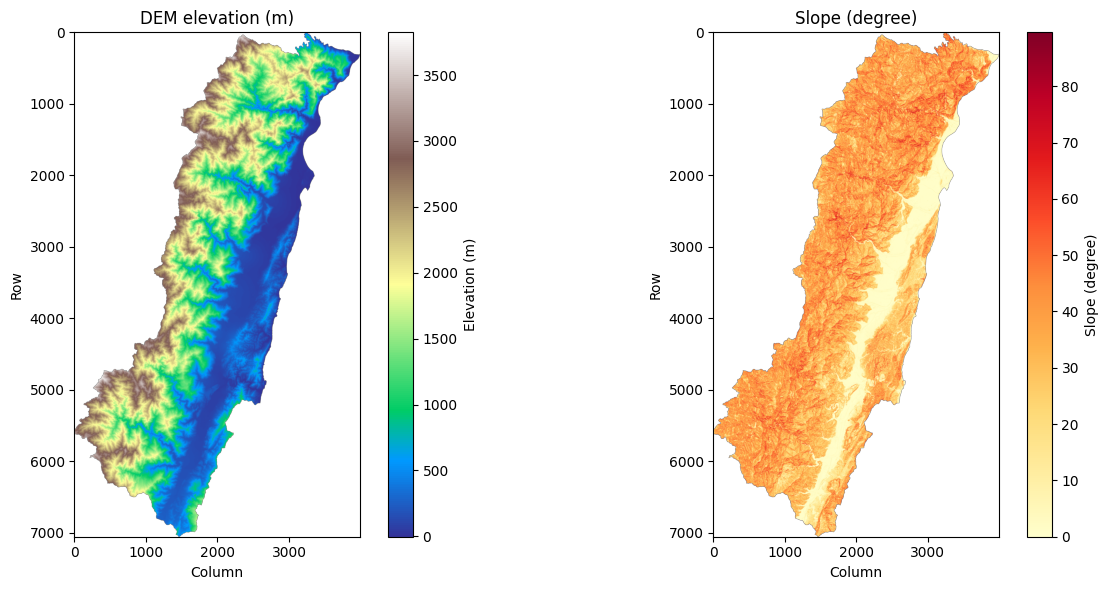

In [39]:
# 修正版：使用dem_data計算坡度並正確顯示高程圖

import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. 從dem_data取得高程資料並處理nodata
# =========================================
# 讀取第一個波段
elevation = dem_data.read(1)

# 取得nodata值並處理
nodata_val = dem_data.nodata
print(f"DEM nodata值: {nodata_val}")

# 將nodata值設為NaN，避免影響計算和顯示
if nodata_val is not None:
    elevation = np.where(elevation == nodata_val, np.nan, elevation)

# 轉換為float類型
elevation = elevation.astype(float)

# =========================================
# 2. 計算坡度
# =========================================
# 使用有限值計算梯度，避免nodata影響
elevation_finite = np.where(np.isfinite(elevation), elevation, 0)
dy, dx = np.gradient(elevation_finite, 20)

# 計算坡度角度
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# 將原本nodata位置的坡度設為NaN
slope_deg = np.where(np.isfinite(elevation), slope_deg, np.nan)

# =========================================
# 3. 坡度統計資訊
# =========================================
slope_min = np.nanmin(slope_deg)
slope_max = np.nanmax(slope_deg)
slope_mean = np.nanmean(slope_deg)
pct_gt_30 = np.nanmean(slope_deg > 30) * 100

print("===== 坡度統計資訊 =====")
print(f"最小坡度: {slope_min:.2f}°")
print(f"最大坡度: {slope_max:.2f}°")
print(f"平均坡度: {slope_mean:.2f}°")
print(f"坡度>30°的像素比例: {pct_gt_30:.2f}%")

# =========================================
# 4. DEM基本資訊
# =========================================
print(f"\n===== DEM 資訊 =====")
print(f"資料形狀: {elevation.shape}")
print(f"解析度: 20m x 20m")
print(f"總像素數: {elevation.size}")
print(f"有效像素數: {np.sum(np.isfinite(elevation))}")
print(f"高程範圍: {np.nanmin(elevation):.1f} ~ {np.nanmax(elevation):.1f} m")

# =========================================
# 5. 視覺化：高程 vs 坡度
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左圖：原始高程 - 修正顯示
# 使用適當的顏色範圍，避免nodata影響
vmin = np.nanmin(elevation)
vmax = np.nanmax(elevation)

im1 = axes[0].imshow(elevation, cmap="terrain", origin="upper", 
                    vmin=vmin, vmax=vmax)
axes[0].set_title("DEM elevation (m)")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label("Elevation (m)")

# 右圖：坡度
im2 = axes[1].imshow(slope_deg, cmap="YlOrRd", origin="upper")
axes[1].set_title("Slope (degree)")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label("Slope (degree)")

plt.tight_layout()
plt.show()

In [40]:
# =========================================
# 6. 將坡度資料儲存為TIFF檔案
# =========================================
import rasterio
from rasterio.transform import from_origin

print("正在儲存坡度資料為TIFF檔案...")

# 設定輸出檔案路徑
output_path = "../data/slope_hualien.tif"

# 取得DEM的地理參考資訊
transform = dem_data.transform
crs = dem_data.crs
height, width = slope_deg.shape

# 將NaN值轉換為nodata值（使用-9999作為nodata）
slope_output = np.where(np.isnan(slope_deg), -9999, slope_deg)

# 儲存坡度資料為TIFF檔案
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=slope_output.dtype,
    crs=crs,
    transform=transform,
    nodata=-9999
) as dst:
    dst.write(slope_output, 1)

print(f"坡度資料已成功儲存至: {output_path}")
print(f"檔案大小: {slope_output.shape}")
print(f"資料類型: {slope_output.dtype}")
print(f"坐標系統: {crs}")

# 驗證檔案是否儲存成功
try:
    with rasterio.open(output_path) as src:
        print(f"\n驗證檔案資訊:")
        print(f"  波段數: {src.count}")
        print(f"  形狀: {src.shape}")
        print(f"  資料類型: {src.dtypes[0]}")
        print(f"  nodata值: {src.nodata}")
        print(f"  坐標系統: {src.crs}")
        
        # 讀取並顯示基本統計
        saved_slope = src.read(1)
        saved_slope = np.where(saved_slope == src.nodata, np.nan, saved_slope)
        
        print(f"\n儲存的坡度統計:")
        print(f"  最小值: {np.nanmin(saved_slope):.2f}°")
        print(f"  最大值: {np.nanmax(saved_slope):.2f}°")
        print(f"  平均值: {np.nanmean(saved_slope):.2f}°")
        
    print(f"\n✓ 檔案 {output_path} 儲存成功並驗證完成")
    
except Exception as e:
    print(f"✗ 檔案儲存或驗證失敗: {e}")

正在儲存坡度資料為TIFF檔案...
坡度資料已成功儲存至: ../data/slope_hualien.tif
檔案大小: (7054, 3997)
資料類型: float64
坐標系統: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

驗證檔案資訊:
  波段數: 1
  形狀: (7054, 3997)
  資料類型: float64
  nodata值: -9999.0
  坐標系統: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Merc

#### 5. 避難所坡度風險等級評估

In [41]:
# 避難所坡度風險等級評估
import numpy as np
import geopandas as gpd
from rasterio import features
from shapely.geometry import box

# =========================================
# 1. 為每個避難所建立300m緩衝區
# =========================================
print("正在為每個避難所建立300m緩衝區...")

# 確保坐標系統與DEM一致（假為EPSG:3824 TWD97）
if shelter_gdf_twd97.crs != dem_data.crs:
    shelter_gdf_twd97 = shelter_gdf_twd97.to_crs(dem_data.crs)

# 建立300m緩衝區
shelter_buffers = shelter_gdf_twd97.geometry.buffer(300)

# =========================================
# 2. 準備raster資訊用於zonal statistics
# =========================================
print("準備raster資訊...")

# 取得DEM的transform和shape
transform = dem_data.transform
height, width = dem_data.shape

# 將坡度資料轉換為與DEM相同的shape
# 確保slope_deg與DEM的shape一致
if slope_deg.shape != (height, width):
    print(f"警告：坡度資料shape {slope_deg.shape} 與DEM shape {(height, width)} 不一致")
    # 如果不一致，需要重新計算或調整

# =========================================
# 3. 計算每個緩衝區的zonal statistics
# =========================================
print("計算各避難所緩衝區的統計資訊...")

avg_slopes = []
max_elevations = []

for i, buffer_geom in enumerate(shelter_buffers):
    if i % 50 == 0:
        print(f"處理進度: {i}/{len(shelter_buffers)}")
    
    try:
        # 將buffer幾何轉換為raster mask
        mask = features.rasterize(
            [(buffer_geom, 1)],
            out_shape=(height, width),
            transform=transform,
            fill=0,
            dtype=np.uint8
        )
        
        # 計算緩衝區內的統計值
        buffer_mask = mask == 1
        
        if np.any(buffer_mask):
            # 計算平均坡度（忽略NaN值）
            slope_in_buffer = slope_deg[buffer_mask]
            avg_slope = np.nanmean(slope_in_buffer)
            
            # 計算最大高程（忽略NaN值）
            elevation_in_buffer = elevation[buffer_mask]
            max_elevation = np.nanmax(elevation_in_buffer)
            
            avg_slopes.append(avg_slope)
            max_elevations.append(max_elevation)
        else:
            # 如果緩衝區內沒有有效資料
            avg_slopes.append(np.nan)
            max_elevations.append(np.nan)
            
    except Exception as e:
        print(f"處理第{i}個避難所時發生錯誤: {e}")
        avg_slopes.append(np.nan)
        max_elevations.append(np.nan)

# =========================================
# 4. 將統計結果新增到GeoDataFrame
# =========================================
print("將統計結果新增到避難所資料...")

shelter_gdf_twd97['Avg_slope'] = avg_slopes
shelter_gdf_twd97['Max_elevation'] = max_elevations

# =========================================
# 5. 根據平均坡度設定風險等級
# =========================================
print("根據平均坡度設定風險等級...")

def assign_slope_risk(avg_slope):
    """根據平均坡度分配風險等級"""
    if pd.isna(avg_slope):
        return 'Unknown'
    elif avg_slope > 30:
        return 'High'
    elif 20 <= avg_slope <= 30:
        return 'Medium'
    else:
        return 'Low'

# 應用風險等級分類
shelter_gdf_twd97['Slope_risk_level'] = shelter_gdf_twd97['Avg_slope'].apply(assign_slope_risk)

# =========================================
# 6. 統計結果顯示
# =========================================
print("\n===== 避難所坡度風險評估結果 =====")
print(f"總避難所數量: {len(shelter_gdf_twd97)}")
print(f"有效統計數量: {shelter_gdf_twd97['Avg_slope'].notna().sum()}")

# 風險等級統計
risk_counts = shelter_gdf_twd97['Slope_risk_level'].value_counts()
print("\n風險等級分布:")
for risk_level, count in risk_counts.items():
    percentage = (count / len(shelter_gdf_twd97)) * 100
    print(f"  {risk_level}: {count} ({percentage:.1f}%)")

# 坡度統計
valid_slopes = shelter_gdf_twd97['Avg_slope'].dropna()
if len(valid_slopes) > 0:
    print(f"\n平均坡度統計:")
    print(f"  最小值: {valid_slopes.min():.2f}°")
    print(f"  最大值: {valid_slopes.max():.2f}°")
    print(f"  平均值: {valid_slopes.mean():.2f}°")

# 高程統計
valid_elevations = shelter_gdf_twd97['Max_elevation'].dropna()
if len(valid_elevations) > 0:
    print(f"\n最大高程統計:")
    print(f"  最小值: {valid_elevations.min():.1f} m")
    print(f"  最大值: {valid_elevations.max():.1f} m")
    print(f"  平均值: {valid_elevations.mean():.1f} m")

# =========================================
# 7. 顯示前10筆結果作為範例
# =========================================
print("\n前10筆避難所評估結果:")
print(shelter_gdf_twd97[['避難收容處所名稱', 'Avg_slope', 'Max_elevation', 'Slope_risk_level']].head(10))

print("\n===== 坡度風險評估完成 =====")

正在為每個避難所建立300m緩衝區...
準備raster資訊...
計算各避難所緩衝區的統計資訊...
處理進度: 0/198
處理進度: 50/198
處理進度: 100/198
處理進度: 150/198
將統計結果新增到避難所資料...
根據平均坡度設定風險等級...

===== 避難所坡度風險評估結果 =====
總避難所數量: 198
有效統計數量: 198

風險等級分布:
  Low: 192 (97.0%)
  Medium: 4 (2.0%)
  High: 2 (1.0%)

平均坡度統計:
  最小值: 0.62°
  最大值: 49.26°
  平均值: 4.72°

最大高程統計:
  最小值: 8.5 m
  最大值: 1378.8 m
  平均值: 130.8 m

前10筆避難所評估結果:
   避難收容處所名稱  Avg_slope  Max_elevation Slope_risk_level
0      和平國小   1.550992      26.299999              Low
1  豐南社區活動中心   5.911457     311.970001              Low
2       玉寶宮   3.268415     248.050003              Low
3  永豐社區活動中心   8.039100     315.700012              Low
4  富里老人文康中心   4.229494     264.399994              Low
5  石平社區活動中心  10.943724     363.209991              Low
6   富里鄉公所2樓   8.842717     311.529999              Low
7  石牌社區活動中心   4.836707     234.949997              Low
8  明里社區活動中心   3.074849     250.229996              Low
9     羅山縱管處   4.788546     259.230011              Low

===== 坡度風險評估完成 =====


In [42]:
shelter_gdf_twd97

,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,管理人電話,室內,室外,適合避難弱者安置,is_indoor,geometry,debrisstream_level,Avg_slope,Max_elevation,Slope_risk_level
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,03-868113,是,否,否,True,POINT (326011.111 2689346.508),Safe,1.550992,26.299999,Low
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,03-8831820,是,否,是,True,POINT (277505.779 2560143.417),High,5.911457,311.970001,Low
2,1332,花蓮縣富里鄉,富南村,富南村4鄰42-1號,121.239900,23.161200,玉寶宮,富南村,20,"水災,土石流",...,03-8831822,是,否,是,True,POINT (274563.447 2562153.682),Safe,3.268415,248.050003,Low
3,1342,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,121.256500,23.171400,永豐社區活動中心,永豐村,50,"水災,土石流",...,03-8831821,是,否,是,True,POINT (276261.145 2563286.086),Low,8.039100,315.700012,Low
4,1350,花蓮縣富里鄉,富里村,中山路205號,121.247624,23.174527,富里老人文康中心,富里村,100,"水災,土石流",...,03-8831048,是,否,是,True,POINT (275351.804 2563630.784),Safe,4.229494,264.399994,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,3392,花蓮縣新城鄉,新城村,博愛路66號,121.650200,24.128800,新城社區活動中心,新城村,23,"水災,震災,土石流,海嘯",...,8611519,是,否,是,True,POINT (316087.333 2669440.771),Safe,2.043808,24.430000,Low
194,3393,花蓮縣新城鄉,新城村,新興1街62號,121.645200,24.130100,興田社區活動中心,新城村,45,"水災,震災,土石流,海嘯",...,8611519,是,否,是,True,POINT (315578.448 2669582.402),Safe,2.005588,31.780001,Low
195,3437,花蓮縣秀林鄉,富世村,97號,121.627700,24.147300,富世活動中心,富世村,100,"水災,震災,土石流,海嘯",...,03-8611829,是,否,是,True,POINT (313791.156 2671479.286),High,12.066074,172.720001,Low
196,3482,花蓮縣秀林鄉,崇德村,72號,121.652400,24.162000,崇德國小收容所,崇德,100,"水災,震災,土石流,海嘯",...,03-8621201,是,否,是,True,POINT (316293.824 2673118.845),High,6.684880,97.339996,Low


In [43]:
# 將shelter_gdf_twd97轉存為CSV檔案
import pandas as pd

print("正在將避難所資料轉存為CSV檔案...")

# 設定輸出檔案路徑
output_csv_path = "../data/shelters_with_analysis_results.csv"

# 移除geometry欄位（因為CSV不支援幾何資料）
shelter_for_csv = shelter_gdf_twd97.drop(columns=['geometry'])

# 將GeoDataFrame轉換為DataFrame並儲存為CSV
shelter_for_csv.to_csv(output_csv_path, index=False, encoding='utf-8-sig')

print(f"避難所資料已成功儲存至: {output_csv_path}")
print(f"總筆數: {len(shelter_for_csv)}")
print(f"總欄位數: {len(shelter_for_csv.columns)}")

# 顯示儲存的欄位名稱
print(f"\n儲存的欄位:")
for i, col in enumerate(shelter_for_csv.columns, 1):
    print(f"  {i:2d}. {col}")

# 顯示前5筆資料作為驗證
print(f"\n前5筆資料預覽:")
print(shelter_for_csv.head())

# 驗證檔案是否成功儲存
try:
    # 讀取儲存的CSV檔案進行驗證
    verification_df = pd.read_csv(output_csv_path, encoding='utf-8-sig')
    print(f"\n✓ CSV檔案驗證成功")
    print(f"  讀取的筆數: {len(verification_df)}")
    print(f"  讀取的欄位數: {len(verification_df.columns)}")
    
    # 檢查重要的分析結果欄位是否存在
    important_columns = ['Avg_slope', 'Max_elevation', 'Slope_risk_level', 'debrisstream_level']
    missing_columns = [col for col in important_columns if col not in verification_df.columns]
    
    if missing_columns:
        print(f"  ⚠️  缺少重要欄位: {missing_columns}")
    else:
        print(f"  ✓ 所有重要分析欄位都存在")
        
    # 顯示風險等級統計
    if 'Slope_risk_level' in verification_df.columns:
        risk_stats = verification_df['Slope_risk_level'].value_counts()
        print(f"\nCSV中的坡度風險等級分布:")
        for risk, count in risk_stats.items():
            print(f"  {risk}: {count}")
            
    if 'debrisstream_level' in verification_df.columns:
        debris_stats = verification_df['debrisstream_level'].value_counts()
        print(f"\nCSV中的土石流風險等級分布:")
        for risk, count in debris_stats.items():
            print(f"  {risk}: {count}")
    
except Exception as e:
    print(f"✗ CSV檔案驗證失敗: {e}")

print(f"\n===== CSV檔案儲存完成 =====")

正在將避難所資料轉存為CSV檔案...
避難所資料已成功儲存至: ../data/shelters_with_analysis_results.csv
總筆數: 198
總欄位數: 20

儲存的欄位:
   1. 序號
   2. 縣市及鄉鎮市區
   3. 村里
   4. 避難收容處所地址
   5. 經度
   6. 緯度
   7. 避難收容處所名稱
   8. 預計收容村里
   9. 預計收容人數
  10. 適用災害類別
  11. 管理人姓名
  12. 管理人電話
  13. 室內
  14. 室外
  15. 適合避難弱者安置
  16. is_indoor
  17. debrisstream_level
  18. Avg_slope
  19. Max_elevation
  20. Slope_risk_level

前5筆資料預覽:
     序號 縣市及鄉鎮市區   村里    避難收容處所地址          經度         緯度  避難收容處所名稱 預計收容村里  \
0    46  花蓮縣秀林鄉  和平村      和平112號  121.748879  24.308073      和平國小   和中部落   
1  1306  花蓮縣富里鄉  豐南村   豐南7鄰12-3號  121.268600  23.143000  豐南社區活動中心    豐南村   
2  1332  花蓮縣富里鄉  富南村  富南村4鄰42-1號  121.239900  23.161200       玉寶宮    富南村   
3  1342  花蓮縣富里鄉  永豐村  永豐10鄰20-1號  121.256500  23.171400  永豐社區活動中心    永豐村   
4  1350  花蓮縣富里鄉  富里村     中山路205號  121.247624  23.174527  富里老人文康中心    富里村   

   預計收容人數        適用災害類別 管理人姓名       管理人電話 室內 室外 適合避難弱者安置  is_indoor  \
0     250        水災,土石流   蔡金郎   03-868113  是  否        否       True   
1      50  水災

#### 6.讀取颱風雨量資料

In [44]:
# 讀取ragasa_with_location.shp檔案並轉換為GeoDataFrame
import geopandas as gpd
import pandas as pd

print("正在讀取ragasa_with_location.shp檔案...")

# 設定檔案路徑
shp_path = "../data/ragasa_shp/ragasa_with_location.shp"

try:
    # 讀取shapefile
    ragasa_gdf = gpd.read_file(shp_path)
    
    print(f"✓ 成功讀取shapefile")
    print(f"  總筆數: {len(ragasa_gdf)}")
    print(f"  坐標系統: {ragasa_gdf.crs}")
    print(f"  幾何類型: {ragasa_gdf.geometry.type.iloc[0] if len(ragasa_gdf) > 0 else 'N/A'}")
    
    # 顯示欄位資訊
    print(f"\n欄位列表:")
    for i, col in enumerate(ragasa_gdf.columns, 1):
        print(f"  {i:2d}. {col}")
    
    # 顯示前5筆資料
    print(f"\n前5筆資料預覽:")
    print(ragasa_gdf.head())
    
    # 檢查幾何資訊
    print(f"\n幾何資訊:")
    if len(ragasa_gdf) > 0:
        bounds = ragasa_gdf.total_bounds
        print(f"  邊界範圍: [{bounds[0]:.2f}, {bounds[1]:.2f}, {bounds[2]:.2f}, {bounds[3]:.2f}]")
        print(f"  (minx, miny, maxx, maxy)")
        
        # 檢查是否有無效幾何
        invalid_geoms = ragasa_gdf[~ragasa_gdf.is_valid].shape[0]
        print(f"  無效幾何數量: {invalid_geoms}")
        
        # 檢查空幾何
        null_geoms = ragasa_gdf.geometry.isna().sum()
        print(f"  空幾何數量: {null_geoms}")
    
    # 基本統計資訊
    print(f"\n基本統計:")
    if 'id' in ragasa_gdf.columns:
        print(f"  ID範圍: {ragasa_gdf['id'].min()} - {ragasa_gdf['id'].max()}")
    
    # 如果坐標系統不是EPSG:3826，提供轉換建議
    if ragasa_gdf.crs != 'EPSG:3826':
        print(f"\n⚠️  注意: 當前坐標系統為 {ragasa_gdf.crs}")
        print(f"  如需與其他資料整合，建議轉換為EPSG:3826:")
        print(f"  ragasa_gdf = ragasa_gdf.to_crs(epsg=3826)")
    
    print(f"\n✓ ragasa_with_location.shp 已成功載入為GeoDataFrame 'ragasa_gdf'")
    print(f"  可直接用於後續分析: ragasa_gdf.head(), ragasa_gdf.plot() 等")
    
except FileNotFoundError:
    print(f"✗ 找不到檔案: {shp_path}")
    print(f"  請確認檔案路徑是否正確")
    
except Exception as e:
    print(f"✗ 讀取shapefile時發生錯誤: {e}")
    print(f"  可能原因: 檔案損壞、權限不足、或格式不支援")

# 可選：如果需要，可以立即轉換坐標系統
try:
     ragasa_gdf_3826 = ragasa_gdf.to_crs(epsg=3826)
     print(f"✓ 已轉換為EPSG:3826坐標系統")
except Exception as e:
     print(f"✗ 坐標轉換失敗: {e}")

正在讀取ragasa_with_location.shp檔案...
✓ 成功讀取shapefile
  總筆數: 35679
  坐標系統: EPSG:4326
  幾何類型: Point

欄位列表:
   1. NID
   2. STID
   3. MIN_10
   4. Hour_1
   5. Hour_3
   6. Hour_6
   7. Hour_12
   8. Hour_24
   9. RST_DATE
  10. Elev
  11. Stationnam
  12. latitude
  13. longtitude
  14. altitude
  15. geometry

前5筆資料預覽:
        NID    STID  MIN_10  Hour_1  Hour_3  Hour_6  Hour_12  Hour_24  \
0  45933777  01T220  -998.0  -998.0  -998.0  -998.0      0.0      0.0   
1  45935019  01T220  -998.0  -998.0  -998.0  -998.0      0.0      0.0   
2  45936261  01T220  -998.0  -998.0  -998.0  -998.0      0.0      0.0   
3  45937503  01T220  -998.0  -998.0  -998.0  -998.0      0.0      0.0   
4  45938745  01T220  -998.0  -998.0  -998.0  -998.0      0.0      0.0   

              RST_DATE   Elev Stationnam   latitude  longtitude  altitude  \
0  2025-09-21 00:00:00  207.0      卓麓(4)  23.295555  121.266945     207.0   
1  2025-09-21 00:10:00  207.0      卓麓(4)  23.295555  121.266945     207.0   
2  2025-09-2

篩選欄位

In [45]:
# 從RST_DATE欄位篩選出2025-09-23 20:00:00的資料
import pandas as pd

print("正在篩選2025-09-23 20:00:00的雨量資料...")

# 確保RST_DATE欄位是datetime格式
if 'RST_DATE' in ragasa_gdf.columns:
    # 如果還不是datetime格式，先轉換
    if not pd.api.types.is_datetime64_any_dtype(ragasa_gdf['RST_DATE']):
        ragasa_gdf['RST_DATE'] = pd.to_datetime(ragasa_gdf['RST_DATE'])
    
    # 設定篩選目標時間
    target_time = pd.to_datetime('2025-09-23 20:00:00')
    
    # 篩選資料
    ragasa_target_time = ragasa_gdf[ragasa_gdf['RST_DATE'] == target_time].copy()
    
    print(f"✓ 篩選完成")
    print(f"  目標時間: {target_time}")
    print(f"  篩選後筆數: {len(ragasa_target_time)}")
    
    if len(ragasa_target_time) > 0:
        # 顯示基本統計
        print(f"\n篩選結果統計:")
        print(f"  有效雨量站數量: {ragasa_target_time['STID'].nunique()}")
        print(f"  時間範圍: {ragasa_target_time['RST_DATE'].min()} - {ragasa_target_time['RST_DATE'].max()}")
        
        # 檢查雨量資料
        rain_cols = ['MIN_10', 'Hour_1', 'Hour_3', 'Hour_6', 'Hour_12', 'Hour_24']
        available_rain_cols = [col for col in rain_cols if col in ragasa_target_time.columns]
        
        if available_rain_cols:
            print(f"\n雨量欄位統計:")
            for col in available_rain_cols:
                # 移除-998無效值後計算統計
                valid_data = ragasa_target_time[ragasa_target_time[col] != -998][col]
                if len(valid_data) > 0:
                    print(f"  {col}: 平均 {valid_data.mean():.2f} mm, 最大 {valid_data.max():.2f} mm, 有效測站 {len(valid_data)}")
                else:
                    print(f"  {col}: 無有效資料")
        
        # 顯示前5筆有效雨量資料
        print(f"\n前5筆有效雨量資料:")
        display_cols = ['STID', 'Stationnam', 'RST_DATE'] + available_rain_cols
        if 'latitude' in ragasa_target_time.columns:
            display_cols.append('latitude')
        if 'longtitude' in ragasa_target_time.columns:
            display_cols.append('longtitude')
        
        print(ragasa_target_time[display_cols].head())
        
        # 儲存篩選結果供後續使用
        ragasa_20250923_2000 = ragasa_target_time.copy()
        print(f"\n✓ 篩選結果已儲存為 'ragasa_20250923_2000'")
        print(f"  可直接用於後續分析: ragasa_20250923_2000.head(), ragasa_20250923_2000.plot() 等")
        
    else:
        print(f"⚠️  未找到目標時間 {target_time} 的資料")
        print(f"  可用時間範圍: {ragasa_gdf['RST_DATE'].min()} - {ragasa_gdf['RST_DATE'].max()}")
        
        # 顯示最接近的時間
        ragasa_gdf_sorted = ragasa_gdf.sort_values('RST_DATE')
        nearest_times = ragasa_gdf_sorted['RST_DATE'].unique()[:10]  # 顯示前10個時間點
        print(f"\n可用的前10個時間點:")
        for i, time in enumerate(nearest_times, 1):
            count = len(ragasa_gdf[ragasa_gdf['RST_DATE'] == time])
            print(f"  {i}. {time} ({count} 筆資料)")

else:
    print(f"✗ 找不到 RST_DATE 欄位")
    print(f"  可用欄位: {list(ragasa_gdf.columns)}")

正在篩選2025-09-23 20:00:00的雨量資料...
✓ 篩選完成
  目標時間: 2025-09-23 20:00:00
  篩選後筆數: 82

篩選結果統計:
  有效雨量站數量: 82
  時間範圍: 2025-09-23 20:00:00 - 2025-09-23 20:00:00

雨量欄位統計:
  MIN_10: 平均 2.76 mm, 最大 15.00 mm, 有效測站 82
  Hour_1: 平均 17.86 mm, 最大 80.00 mm, 有效測站 82
  Hour_3: 平均 52.46 mm, 最大 155.00 mm, 有效測站 82
  Hour_6: 平均 86.67 mm, 最大 196.50 mm, 有效測站 82
  Hour_12: 平均 156.54 mm, 最大 356.00 mm, 有效測站 82
  Hour_24: 平均 280.35 mm, 最大 611.50 mm, 有效測站 82

前5筆有效雨量資料:
        STID Stationnam            RST_DATE  MIN_10  Hour_1  Hour_3  Hour_6  \
811   01T230         立山 2025-09-23 20:00:00     0.0    43.0   122.0   151.0   
1180  01T220      卓麓(4) 2025-09-23 20:00:00     0.0    19.0    67.0   112.0   
1998  01T560         西林 2025-09-23 20:00:00     0.0    15.0    28.0   100.0   
3225  01T9J0       六十石山 2025-09-23 20:00:00     0.0    20.0    54.0    77.0   
3265  01T500         北埔 2025-09-23 20:00:00     0.0     3.0    28.0    53.0   

      Hour_12  Hour_24   latitude  longtitude  
811     248.0    368.0  23.430079

#### 7. 三種模型分析

正在進行Variogram分析比較三種模型...
有效測站數量: 82
坐標系統: EPSG:3826
雨量範圍: 0.0 - 80.0 mm


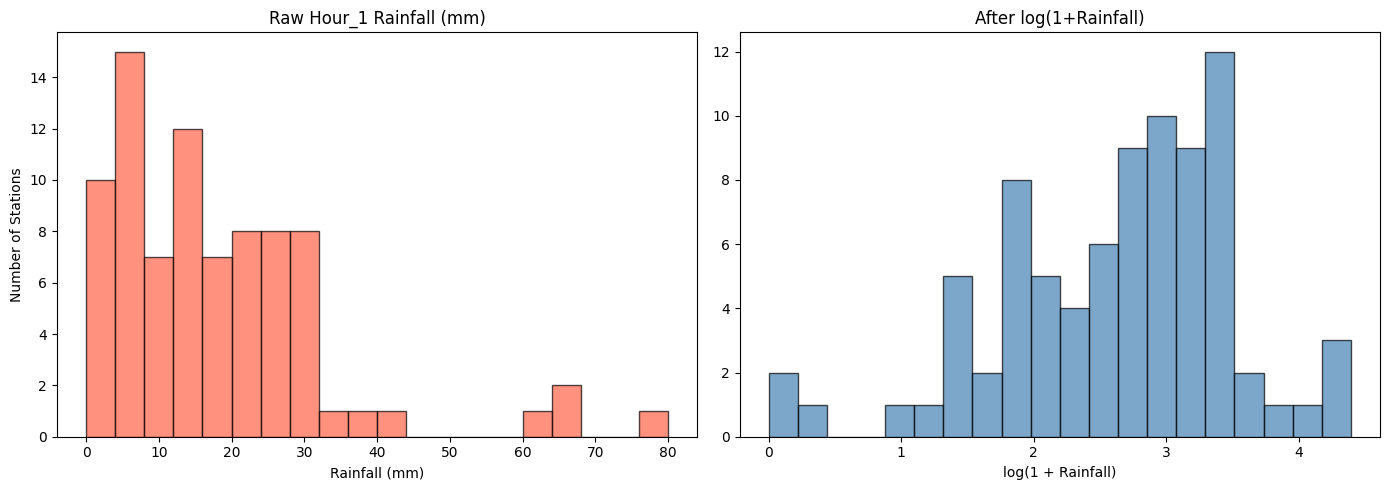


使用對數轉換資料進行分析

開始模型比較...


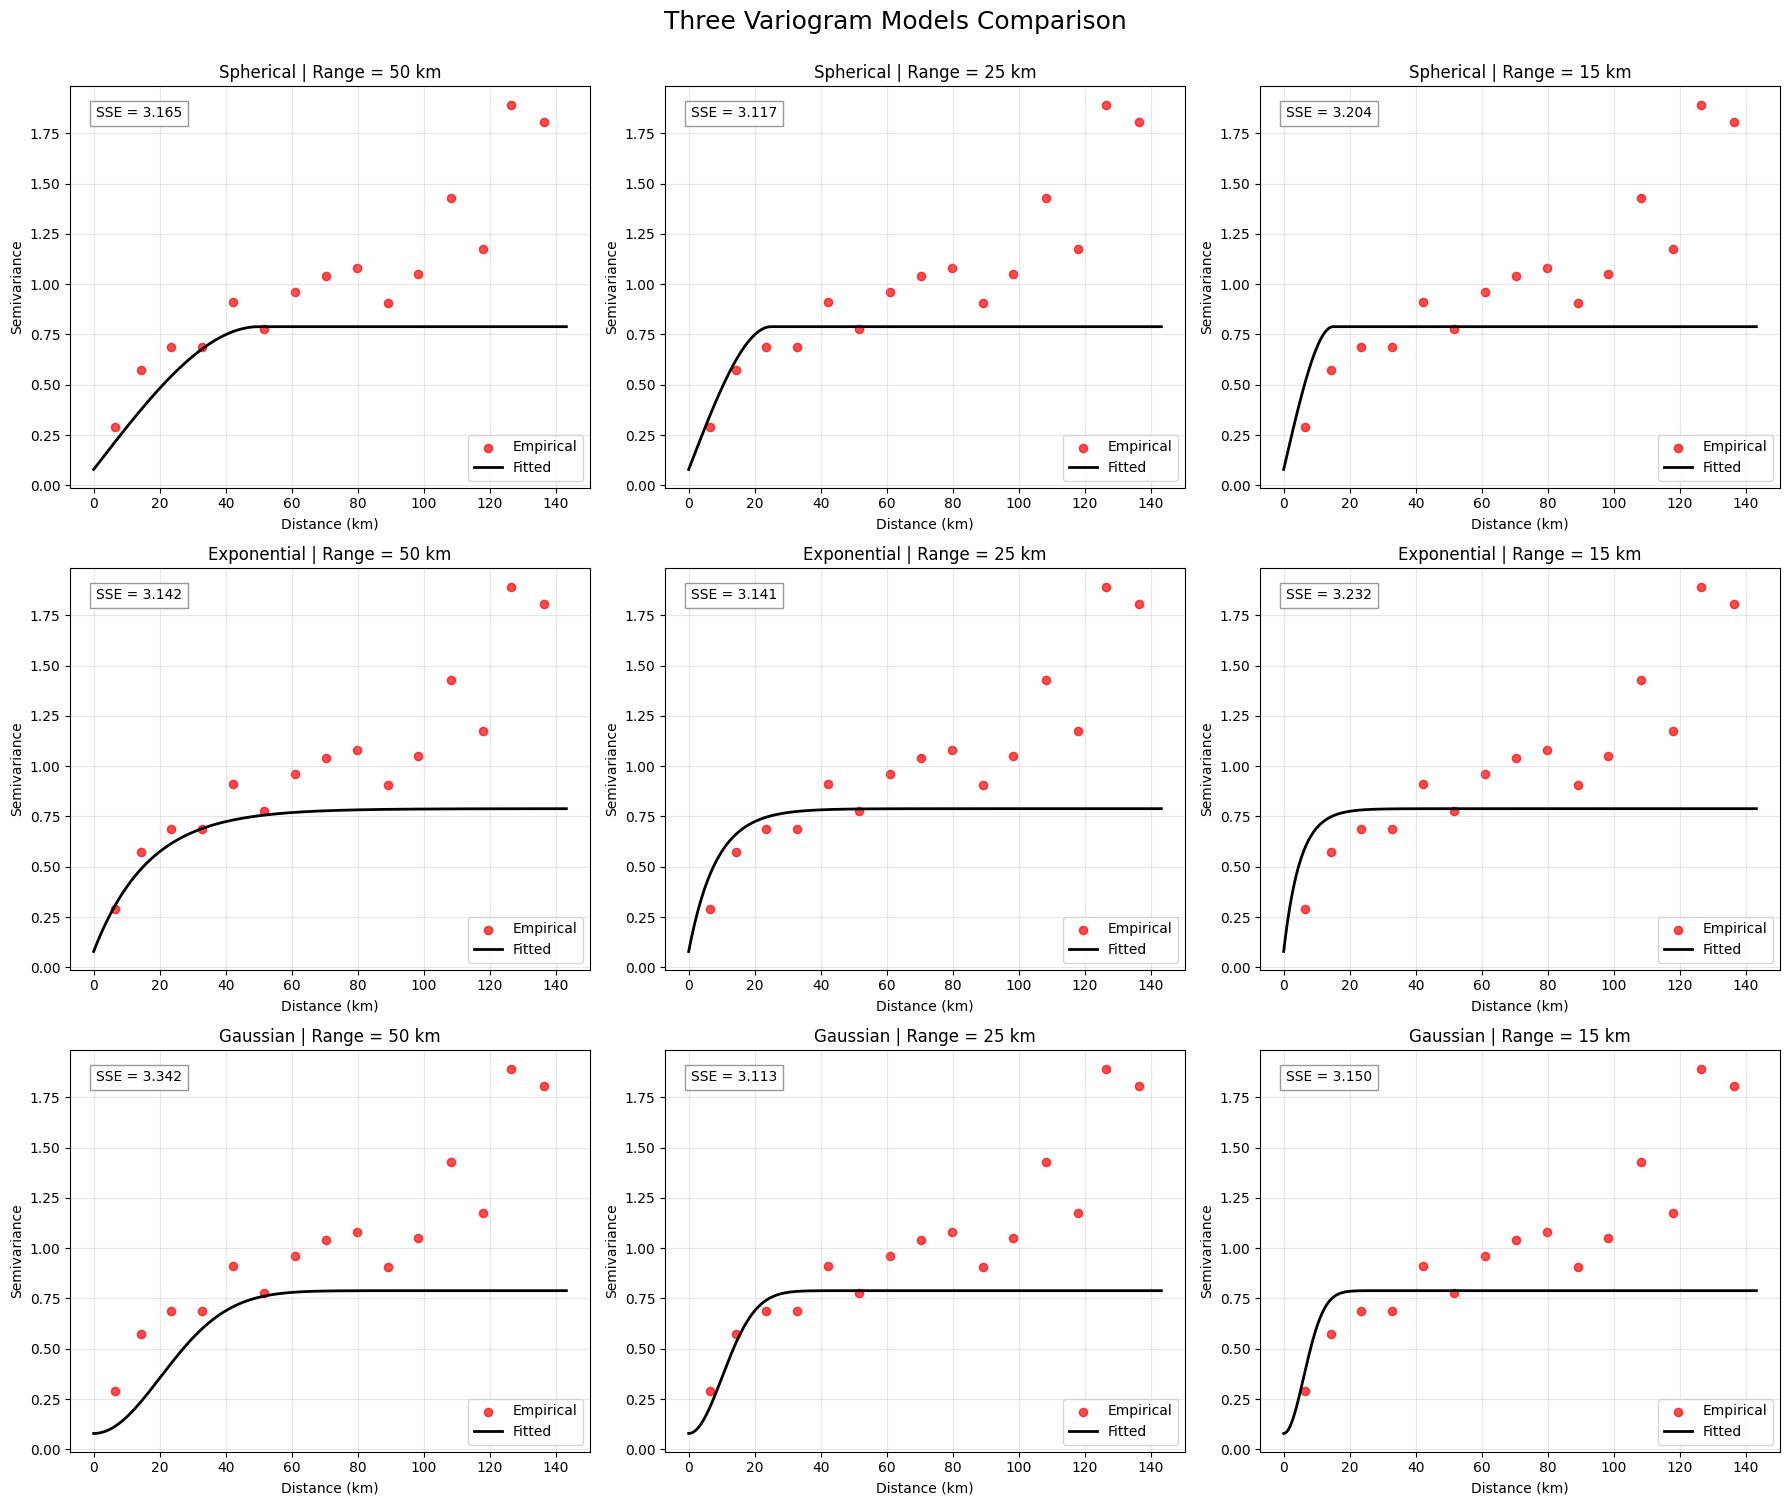


===== 模型比較結果 =====
      model  range_km     sill  range_m   nugget      SSE
   gaussian        25 0.710018  25000.0 0.078891 3.112817
  spherical        25 0.710018  25000.0 0.078891 3.116883
exponential        25 0.710018  25000.0 0.078891 3.140907
exponential        50 0.710018  50000.0 0.078891 3.141986
   gaussian        15 0.710018  15000.0 0.078891 3.150065
  spherical        50 0.710018  50000.0 0.078891 3.164800
  spherical        15 0.710018  15000.0 0.078891 3.204408
exponential        15 0.710018  15000.0 0.078891 3.232479
   gaussian        50 0.710018  50000.0 0.078891 3.341646

最佳擬合模型:
  模型: gaussian
  範圍: 25 km
  SSE: 3.113
  參數: Sill=0.710, Range=25000m, Nugget=0.079

===== 各模型最佳結果 =====
Spherical   : Range=25km, SSE=3.117
Exponential : Range=25km, SSE=3.141
Gaussian    : Range=25km, SSE=3.113

===== 模型間比較 =====

Range = 50 km:
  exponential : SSE = 3.142
  spherical   : SSE = 3.165
  gaussian    : SSE = 3.342

Range = 25 km:
  gaussian    : SSE = 3.113
  spherical   

In [46]:
# Variogram分析：比較 spherical / exponential / gaussian 三種模型
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

print("正在進行Variogram分析比較三種模型...")

# 1. 準備資料
# 確保坐標系統為EPSG:3826（公尺單位）
if ragasa_20250923_2000.crs != 'EPSG:3826':
    ragasa_analysis = ragasa_20250923_2000.to_crs(epsg=3826)
else:
    ragasa_analysis = ragasa_20250923_2000.copy()

# 提取坐標和雨量資料
x = ragasa_analysis.geometry.x.values  # Easting (meters)
y = ragasa_analysis.geometry.y.values  # Northing (meters)
z = ragasa_analysis['Hour_1'].values   # 1小時累積雨量

# 移除無效值
valid_mask = (z != -998) & (~np.isnan(z))
x_valid = x[valid_mask]
y_valid = y[valid_mask]
z_valid = z[valid_mask]

print(f"有效測站數量: {len(z_valid)}")
print(f"坐標系統: {ragasa_analysis.crs}")
print(f"雨量範圍: {z_valid.min():.1f} - {z_valid.max():.1f} mm")

# 2. 檢查資料分布，決定是否需要對數轉換
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(z_valid, bins=20, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('Raw Hour_1 Rainfall (mm)')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Number of Stations')

# 對數轉換
z_log = np.log1p(z_valid)
axes[1].hist(z_log, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('After log(1+Rainfall)')
axes[1].set_xlabel('log(1 + Rainfall)')
plt.tight_layout()
plt.show()

# 決定使用原始資料還是對數轉換資料
use_log = True  # 根據分布決定
z_analysis = z_log if use_log else z_valid

print(f"\n使用{'對數轉換' if use_log else '原始'}資料進行分析")

# 3. 三種模型比較分析
models = ['spherical', 'exponential', 'gaussian']
ranges_km = [50, 25, 15]  # 測試不同範圍
ranges_m = [r * 1000 for r in ranges_km]

results = []

print(f"\n開始模型比較...")

def plot_variogram_comparison(model_name, axes):
    """繪製變異圖比較"""
    for ax, rkm, rm in zip(axes, ranges_km, ranges_m):
        sill = float(z_analysis.var())
        nugget = float(z_analysis.var() * 0.1)

        try:
            ok_test = OrdinaryKriging(
                x_valid, y_valid, z_analysis,
                variogram_model=model_name,
                verbose=False,
                enable_plotting=False,
                nlags=15,
                variogram_parameters={
                    'sill': sill,
                    'range': float(rm),
                    'nugget': nugget
                }
            )

            # 實證變異圖
            lags_km = ok_test.lags / 1000.0
            empirical = ok_test.semivariance

            # 擬合模型曲線
            params = ok_test.variogram_model_parameters
            dist_line = np.linspace(0, np.max(ok_test.lags) * 1.05, 300)
            model_line = ok_test.variogram_function(params, dist_line)

            # 計算SSE
            fitted_at_lags = ok_test.variogram_function(params, ok_test.lags)
            sse = float(np.sum((empirical - fitted_at_lags) ** 2))

            # 繪圖
            ax.scatter(lags_km, empirical, c='red', s=35, label='Empirical', alpha=0.7)
            ax.plot(dist_line / 1000.0, model_line, c='black', linewidth=2, label='Fitted')
            ax.set_title(f"{model_name.capitalize()} | Range = {rkm} km")
            ax.set_xlabel("Distance (km)")
            ax.set_ylabel("Semivariance")
            ax.grid(alpha=0.3)
            ax.legend()

            # 顯示SSE
            ax.text(0.05, 0.95, f"SSE = {sse:.3f}", 
                   transform=ax.transAxes, ha='left', va='top',
                   fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

            results.append({
                "model": model_name,
                "range_km": rkm,
                "sill": float(params[0]),
                "range_m": float(params[1]),
                "nugget": float(params[2]),
                "SSE": sse
            })

        except Exception as e:
            print(f"  {model_name} Range {rkm}km 失敗: {e}")
            continue

# 4. 繪製比較圖
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, model in enumerate(models):
    model_axes = axes[i*3:(i+1)*3]
    plot_variogram_comparison(model, model_axes)

plt.suptitle('Three Variogram Models Comparison', fontsize=18, y=1.0)
plt.tight_layout()
plt.show()

# 5. 結果分析
summary_df = pd.DataFrame(results)
if not summary_df.empty:
    summary_df = summary_df.sort_values("SSE").reset_index(drop=True)
    
    print(f"\n===== 模型比較結果 =====")
    print(summary_df.to_string(index=False))
    
    # 找出最佳模型
    best_model = summary_df.iloc[0]
    print(f"\n最佳擬合模型:")
    print(f"  模型: {best_model['model']}")
    print(f"  範圍: {best_model['range_km']} km")
    print(f"  SSE: {best_model['SSE']:.3f}")
    print(f"  參數: Sill={best_model['sill']:.3f}, Range={best_model['range_m']:.0f}m, Nugget={best_model['nugget']:.3f}")
    
    # 各模型內的最佳結果
    print(f"\n===== 各模型最佳結果 =====")
    for model in models:
        model_best = summary_df[summary_df['model'] == model].iloc[0]
        print(f"{model.capitalize():12s}: Range={model_best['range_km']}km, SSE={model_best['SSE']:.3f}")
    
    # 模型間比較
    print(f"\n===== 模型間比較 =====")
    for rkm in ranges_km:
        subset = summary_df[summary_df['range_km'] == rkm].sort_values("SSE")
        print(f"\nRange = {rkm} km:")
        for _, row in subset.iterrows():
            print(f"  {row['model']:12s}: SSE = {row['SSE']:.3f}")

else:
    print("✗ 所有模型擬合都失敗")

print(f"\n===== Variogram分析完成 =====")

#### 8. 運用PyKrige OrdinaryKriging 進行空間插值

正在進行Ordinary Kriging空間插值...
使用模型參數:
  模型: gaussian
  範圍: 25.0 km
  Sill: 0.789
  Nugget: 0.079
✓ Kriging模型建立完成 (0.00s)
插值網格: 79×156 = 12,324 點 @ 1000m解析度
✓ Kriging插值完成 (0.05s)
插值結果統計:
  降雨範圍: 0.71 - 49.40 mm
  平均降雨: 12.83 mm
  Sigma範圍: 0.0936 - 0.8591


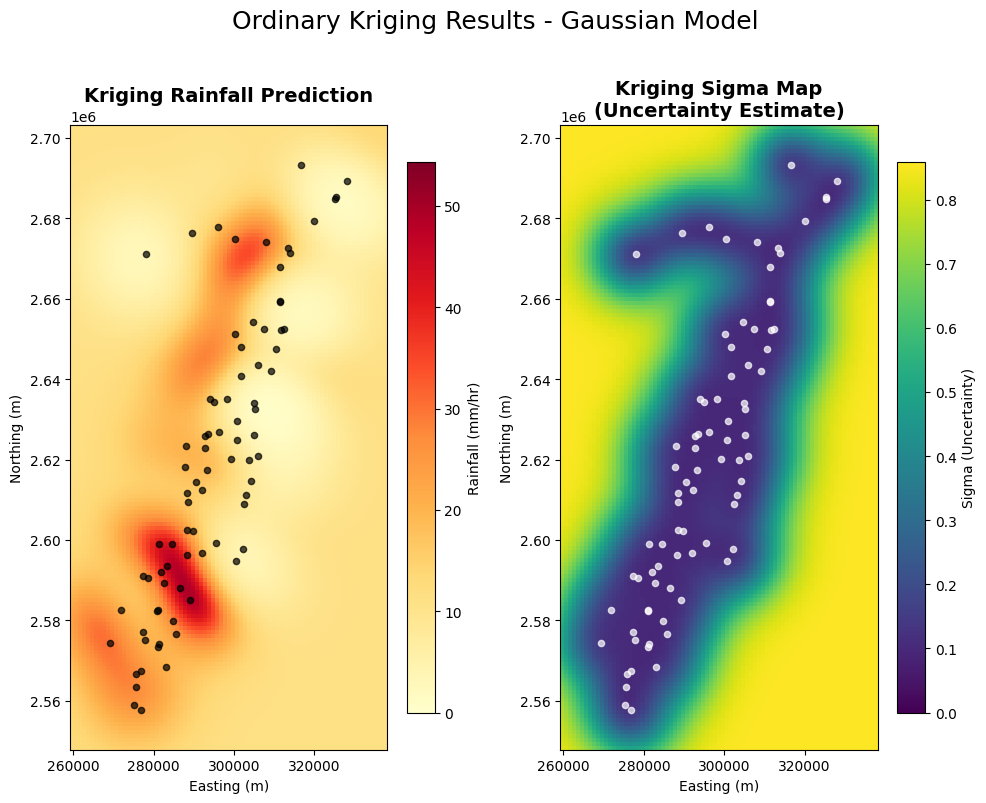


===== Kriging插值結果摘要 =====
網格解析度: 1000m
網格大小: 79 × 156
總插值點數: 12,324
有效插值點數: 12,324

降雨預測統計:
  最小值: 0.71 mm/hr
  最大值: 49.40 mm/hr
  平均值: 12.83 mm/hr
  標準差: 7.63 mm/hr

不確定性統計:
  最小值: 0.0936
  最大值: 0.8591
  平均值: 0.5171
  標準差: 0.2917

不確定性分類:
  低不確定性 (< 0.3018): 4,067 點 (33.0%)
  中不確定性 (0.3018 - 0.7658): 4,067 點 (33.0%)
  高不確定性 (> 0.7658): 4,190 點 (34.0%)

===== Kriging插值分析完成 =====


c:\Users\97000\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [47]:
# PyKrige OrdinaryKriging 空間插值分析
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
import time

print("正在進行Ordinary Kriging空間插值...")

# 1. 使用最佳模型參數（根據前面Variogram分析的結果）
best_model = 'gaussian'  # 請根據前面分析結果修改
best_range = 25000.0     # 請根據前面分析結果修改
best_sill = float(z_analysis.var())
best_nugget = float(z_analysis.var() * 0.1)

print(f"使用模型參數:")
print(f"  模型: {best_model}")
print(f"  範圍: {best_range/1000:.1f} km")
print(f"  Sill: {best_sill:.3f}")
print(f"  Nugget: {best_nugget:.3f}")

# 2. 建立Ordinary Kriging模型
t0 = time.time()
OK = OrdinaryKriging(
    x_valid, y_valid, z_analysis,
    variogram_model=best_model,
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        'sill': best_sill,
        'range': best_range,
        'nugget': best_nugget
    }
)
print(f"✓ Kriging模型建立完成 ({time.time()-t0:.2f}s)")

# 3. 定義插值網格
buffer_m = 10000  # 10km緩衝區
resolution = 1000  # 1km解析度

# 計算網格範圍
x_min = x_valid.min() - buffer_m
x_max = x_valid.max() + buffer_m
y_min = y_valid.min() - buffer_m
y_max = y_valid.max() + buffer_m

# 建立規則網格
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"插值網格: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} 點 @ {resolution}m解析度")

# 4. 執行Kriging插值
t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging插值完成 ({time.time()-t0:.2f}s)")

# 5. 轉換回原始雨量單位（如果使用了對數轉換）
if use_log:
    z_kriging = np.expm1(z_kriging_log)  # exp(log(1+z)) - 1 = z
    z_kriging[z_kriging < 0] = 0  # 確保非負值
    ss_kriging = ss_kriging_log  # Sigma保持對數空間
else:
    z_kriging = z_kriging_log
    ss_kriging = ss_kriging_log

print(f"插值結果統計:")
print(f"  降雨範圍: {np.nanmin(z_kriging):.2f} - {np.nanmax(z_kriging):.2f} mm")
print(f"  平均降雨: {np.nanmean(z_kriging):.2f} mm")
print(f"  Sigma範圍: {np.nanmin(ss_kriging):.4f} - {np.nanmax(ss_kriging):.4f}")

# 6. 視覺化結果 - 只顯示兩張子圖
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# 設定共同的顏色範圍
vmax_rain = np.nanmax(z_kriging) * 1.1
vmax_sigma = np.nanmax(ss_kriging)

# 左圖：Kriging降雨預測
im1 = axes[0].imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd',
    vmin=0,
    vmax=vmax_rain
)

# 叠加原始測站點
axes[0].scatter(x_valid, y_valid, c='black', s=20, zorder=5, alpha=0.7)
axes[0].set_title('Kriging Rainfall Prediction', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
cbar1 = plt.colorbar(im1, ax=axes[0], shrink=0.8)
cbar1.set_label('Rainfall (mm/hr)')

# 右圖：Kriging Sigma Map（不確定性）
im2 = axes[1].imshow(
    ss_kriging,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='viridis',
    vmin=0,
    vmax=vmax_sigma
)

axes[1].scatter(x_valid, y_valid, c='white', s=20, zorder=5, alpha=0.7)
axes[1].set_title('Kriging Sigma Map\n(Uncertainty Estimate)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
cbar2 = plt.colorbar(im2, ax=axes[1], shrink=0.8)
cbar2.set_label('Sigma (Uncertainty)')

plt.suptitle(f'Ordinary Kriging Results - {best_model.capitalize()} Model', fontsize=18, y=1.0)
plt.tight_layout()
plt.show()

# 7. 輸出統計摘要
print(f"\n===== Kriging插值結果摘要 =====")
print(f"網格解析度: {resolution}m")
print(f"網格大小: {len(grid_x)} × {len(grid_y)}")
print(f"總插值點數: {len(grid_x) * len(grid_y):,}")
print(f"有效插值點數: {np.sum(~np.isnan(z_kriging)):,}")

print(f"\n降雨預測統計:")
print(f"  最小值: {np.nanmin(z_kriging):.2f} mm/hr")
print(f"  最大值: {np.nanmax(z_kriging):.2f} mm/hr")
print(f"  平均值: {np.nanmean(z_kriging):.2f} mm/hr")
print(f"  標準差: {np.nanstd(z_kriging):.2f} mm/hr")

print(f"\n不確定性統計:")
print(f"  最小值: {np.nanmin(ss_kriging):.4f}")
print(f"  最大值: {np.nanmax(ss_kriging):.4f}")
print(f"  平均值: {np.nanmean(ss_kriging):.4f}")
print(f"  標準差: {np.nanstd(ss_kriging):.4f}")

# 不確定性分類統計（保留數值分析但移除圖表）
sigma_33 = np.nanpercentile(ss_kriging, 33)
sigma_66 = np.nanpercentile(ss_kriging, 66)

low_uncertainty = np.sum(ss_kriging < sigma_33)
med_uncertainty = np.sum((ss_kriging >= sigma_33) & (ss_kriging < sigma_66))
high_uncertainty = np.sum(ss_kriging >= sigma_66)
total_points = np.sum(~np.isnan(ss_kriging))

print(f"\n不確定性分類:")
print(f"  低不確定性 (< {sigma_33:.4f}): {low_uncertainty:,} 點 ({low_uncertainty/total_points*100:.1f}%)")
print(f"  中不確定性 ({sigma_33:.4f} - {sigma_66:.4f}): {med_uncertainty:,} 點 ({med_uncertainty/total_points*100:.1f}%)")
print(f"  高不確定性 (> {sigma_66:.4f}): {high_uncertainty:,} 點 ({high_uncertainty/total_points*100:.1f}%)")

print(f"\n===== Kriging插值分析完成 =====")

#### 9.提取避難所的雨量插值

正在提取避難所點位的雨量值...
✓ 成功為 198 個避難所提取雨量值
✓ 已確認欄位 rain_1hr 與 sigma_1hr 存在


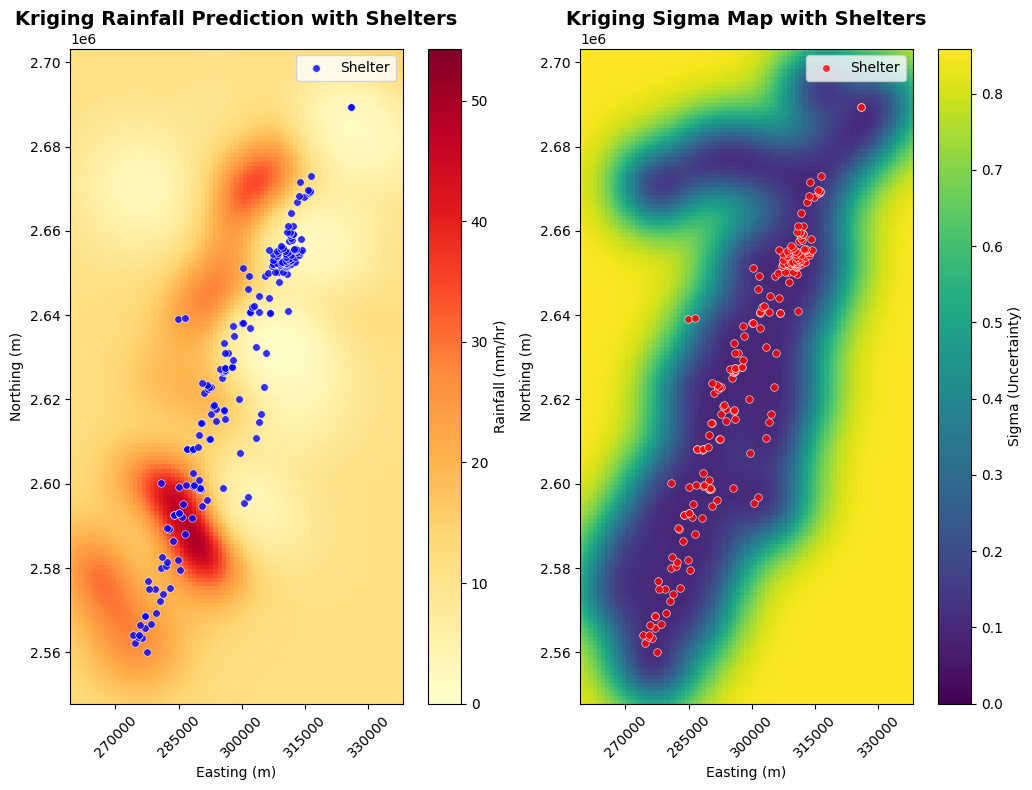


===== 避難所雨量統計 =====
         rain_1hr   sigma_1hr
count  198.000000  198.000000
mean    13.630023    0.107197
std     11.143146    0.035245
min      0.960991    0.094114
25%      4.663534    0.097364
50%      9.301758    0.100590
75%     19.737805    0.106459
max     48.168233    0.462510

===== 避難所雨量資料範例 =====
   避難收容處所名稱   rain_1hr  sigma_1hr
0      和平國小   2.659960   0.131210
1  豐南社區活動中心  25.080535   0.109780
2       玉寶宮  27.263645   0.112761
3  永豐社區活動中心  26.692346   0.100447
4  富里老人文康中心  27.387960   0.103310
5  石平社區活動中心  27.843876   0.111826
6   富里鄉公所2樓  27.387960   0.103310
7  石牌社區活動中心  25.549289   0.100636
8  明里社區活動中心  26.101571   0.100657
9     羅山縱管處  24.207342   0.101780

有效避難所雨量資料: 198/198
平均避難所雨量: 13.63 mm/hr
最大避難所雨量: 48.17 mm/hr


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from matplotlib.ticker import MaxNLocator
from matplotlib import gridspec

print("正在提取避難所點位的雨量值...")

# ============================================================
# 1. 執行提取避難所點位雨量值
# ============================================================

shelter_gdf_twd97 = extract_shelter_values(
    grid_x,
    grid_y,
    z_kriging,
    ss_kriging,
    shelter_gdf_twd97
)

# ============================================================
# 2. 統一欄位名稱，避免後面統計時發生 KeyError
# ============================================================

# 如果函數產生的是 rainfall_value / rainfall_std，就改成 rain_1hr / sigma_1hr
rename_dict = {}

if 'rainfall_value' in shelter_gdf_twd97.columns:
    rename_dict['rainfall_value'] = 'rain_1hr'

if 'rainfall_std' in shelter_gdf_twd97.columns:
    rename_dict['rainfall_std'] = 'sigma_1hr'

if len(rename_dict) > 0:
    shelter_gdf_twd97 = shelter_gdf_twd97.rename(columns=rename_dict)

# 檢查欄位是否真的存在
required_cols = ['rain_1hr', 'sigma_1hr']
missing_cols = [col for col in required_cols if col not in shelter_gdf_twd97.columns]

if len(missing_cols) > 0:
    raise KeyError(
        f"缺少欄位: {missing_cols}。\n"
        f"目前 shelter_gdf_twd97 的欄位有:\n{shelter_gdf_twd97.columns.tolist()}"
    )

print(f"✓ 成功為 {len(shelter_gdf_twd97)} 個避難所提取雨量值")
print("✓ 已確認欄位 rain_1hr 與 sigma_1hr 存在")

# ============================================================
# 3. 使用 gridspec 建立子圖
# ============================================================

fig = plt.figure(figsize=(11, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.0, hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ============================================================
# 4. 雨量插值圖
# ============================================================

im1 = ax1.imshow(
    z_kriging,
    extent=[x_min, x_max, y_min, y_max],
    cmap='YlOrRd',
    origin='lower',
    vmin=0,
    vmax=np.nanmax(z_kriging) * 1.1
)

ax1.set_title(
    'Kriging Rainfall Prediction with Shelters',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')

plt.colorbar(im1, ax=ax1, label='Rainfall (mm/hr)')

# 重疊避難所點位
ax1.scatter(
    shelter_gdf_twd97.geometry.x,
    shelter_gdf_twd97.geometry.y,
    c='blue',
    s=30,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5,
    label='Shelter'
)

ax1.legend()
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax1.tick_params(axis='x', rotation=45)

# ============================================================
# 5. Kriging 不確定性圖
# ============================================================

im2 = ax2.imshow(
    ss_kriging,
    extent=[x_min, x_max, y_min, y_max],
    cmap='viridis',
    origin='lower',
    vmin=0,
    vmax=np.nanmax(ss_kriging)
)

ax2.set_title(
    'Kriging Sigma Map with Shelters',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel('Easting (m)')
ax2.set_ylabel('Northing (m)')

plt.colorbar(im2, ax=ax2, label='Sigma (Uncertainty)')

# 重疊避難所點位
ax2.scatter(
    shelter_gdf_twd97.geometry.x,
    shelter_gdf_twd97.geometry.y,
    c='red',
    s=30,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5,
    label='Shelter'
)

ax2.legend()
ax2.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 6. 避難所雨量統計
# ============================================================

print("\n===== 避難所雨量統計 =====")
print(shelter_gdf_twd97[['rain_1hr', 'sigma_1hr']].describe())

print("\n===== 避難所雨量資料範例 =====")

display_cols = ['rain_1hr', 'sigma_1hr']

if '避難收容處所名稱' in shelter_gdf_twd97.columns:
    display_cols = ['避難收容處所名稱', 'rain_1hr', 'sigma_1hr']

print(shelter_gdf_twd97[display_cols].head(10))

valid_shelters = shelter_gdf_twd97.dropna(subset=['rain_1hr'])

print(f"\n有效避難所雨量資料: {len(valid_shelters)}/{len(shelter_gdf_twd97)}")
print(f"平均避難所雨量: {valid_shelters['rain_1hr'].mean():.2f} mm/hr")
print(f"最大避難所雨量: {valid_shelters['rain_1hr'].max():.2f} mm/hr")

#### 10. 運用RF做雨量推估

In [49]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=== Random Forest 雨量推估分析 ===")
print("使用 ragasa_20250923_2000 資料進行模型訓練與參數優化")

# 1. 準備訓練數據（假設 x_valid, y_valid, z_analysis 已準備好）
print(f"\n1. 數據準備")
print(f"   訓練樣本數: {len(x_valid)}")
print(f"   X 特徵: [經度, 緯度]")
print(f"   y 目標: 1小時累積雨量")

# 準備特徵矩陣
X_train = np.column_stack([x_valid, y_valid])
y_train = z_valid

print(f"   特徵矩陣形狀: {X_train.shape}")
print(f"   目標變數範圍: {np.min(y_train):.2f} - {np.max(y_train):.2f} mm")

# 2. Grid Search 參數優化
print(f"\n2. Grid Search 參數優化中...")

# 定義參數網格
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2', None]
}

# 建立 Random Forest 模型
rf_base = RandomForestRegressor(random_state=42)

# Grid Search（5折交叉驗證）
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 執行 Grid Search
t0 = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - t0

# 3. 最佳參數結果
print(f"\n3. Grid Search 完成 ({grid_time:.1f}s)")
print(f"   最佳 R² 分數: {grid_search.best_score_:.3f}")
print(f"   最佳參數: {grid_search.best_params_}")

# 使用最佳模型
best_rf = grid_search.best_estimator_

# 4. 訓練集評估
print(f"\n4. 模型評估")

# 訓練集預測
y_train_pred = best_rf.predict(X_train)

# 計算各種評估指標
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)

print(f"   訓練集 R²: {train_r2:.3f}")
print(f"   訓練集 RMSE: {train_rmse:.2f} mm/hr")
print(f"   訓練集 MAE: {train_mae:.2f} mm/hr")

# 5. 特徵重要性分析
print(f"\n5. 特徵重要性")
importances = best_rf.feature_importances_
feature_names = ['經度 (X)', '緯度 (Y)']

for i, (name, importance) in enumerate(zip(feature_names, importances)):
    print(f"   {name}: {importance:.3f} ({importance*100:.1f}%)")

print(f"   模型主要依賴: {'經度' if importances[0] > importances[1] else '緯度'}")

# 6. 交叉驗證評估
print(f"\n6. 交叉驗證結果")
cv_scores = grid_search.cv_results_['mean_test_score']
best_cv_score = np.max(cv_scores)
print(f"   最佳 CV R²: {best_cv_score:.3f}")
print(f"   CV R² 標準差: {np.std(cv_scores):.3f}")

# 7. 模型統計摘要
print(f"\n7. 模型統計摘要")
print(f"   樹的數量: {best_rf.n_estimators}")
print(f"   最大深度: {best_rf.max_depth}")
print(f"   葉子最小樣本: {best_rf.min_samples_leaf}")
print(f"   分割最小樣本: {best_rf.min_samples_split}")

# 8. 預測範圍檢查
print(f"\n8. 預測能力檢查")
y_pred_range = best_rf.predict(X_train)
print(f"   預測範圍: {np.min(y_pred_range):.2f} - {np.max(y_pred_range):.2f} mm/hr")
print(f"   實際範圍: {np.min(y_train):.2f} - {np.max(y_train):.2f} mm/hr")

# 9. 與基準模型比較
print(f"\n9. 與基準模型比較")
# 簡單平均基準
baseline_pred = np.full_like(y_train, np.mean(y_train))
baseline_r2 = r2_score(y_train, baseline_pred)

print(f"   平均基準 R²: {baseline_r2:.3f}")
print(f"   RF 改進幅度: {(train_r2 - baseline_r2):.3f}")

print(f"\n=== Random Forest 訓練完成 ===")
print(f"✓ 最佳模型已準備好用於空間插值")
print(f"✓ 總執行時間: {grid_time:.1f}s")
print(f"✓ 模型性能: R² = {train_r2:.3f}")

=== Random Forest 雨量推估分析 ===
使用 ragasa_20250923_2000 資料進行模型訓練與參數優化

1. 數據準備
   訓練樣本數: 82
   X 特徵: [經度, 緯度]
   y 目標: 1小時累積雨量
   特徵矩陣形狀: (82, 2)
   目標變數範圍: 0.00 - 80.00 mm

2. Grid Search 參數優化中...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

3. Grid Search 完成 (29.1s)
   最佳 R² 分數: 0.442
   最佳參數: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

4. 模型評估
   訓練集 R²: 0.928
   訓練集 RMSE: 4.05 mm/hr
   訓練集 MAE: 2.52 mm/hr

5. 特徵重要性
   經度 (X): 0.528 (52.8%)
   緯度 (Y): 0.472 (47.2%)
   模型主要依賴: 經度

6. 交叉驗證結果
   最佳 CV R²: 0.442
   CV R² 標準差: 0.043

7. 模型統計摘要
   樹的數量: 300
   最大深度: 20
   葉子最小樣本: 1
   分割最小樣本: 2

8. 預測能力檢查
   預測範圍: 1.12 - 61.15 mm/hr
   實際範圍: 0.00 - 80.00 mm/hr

9. 與基準模型比較
   平均基準 R²: 0.000
   RF 改進幅度: 0.928

=== Random Forest 訓練完成 ===
✓ 最佳模型已準備好用於空間插值
✓ 總執行時間: 29.1s
✓ 模型性能: R² = 0.928


c:\Users\97000\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


#### 11. 運用RF進行避難所與雨量預測

In [50]:
import numpy as np
import pandas as pd
import time

print("=== Random Forest 避難所雨量推估 ===")
print("使用訓練好的模型對 shelter_gdf_twd97 進行雨量預測")

# 1. 檢查避難所資料
print(f"\n1. 避難所資料檢查")
print(f"   避難所總數: {len(shelter_gdf_twd97)}")
print(f"   資料欄位: {list(shelter_gdf_twd97.columns)}")

# 2. 準備避難所座標特徵
print(f"\n2. 準備預測特徵")

# 提取避難所的經緯度座標
# 假設 geometry 欄位包含點位資訊
if 'geometry' in shelter_gdf_twd97.columns:
    shelter_x = shelter_gdf_twd97.geometry.x.values  # 經度
    #print(shelter_x)
    shelter_y = shelter_gdf_twd97.geometry.y.values  # 緯度
    #print(shelter_y)
    print(f"   ✓ 從 geometry 欄位提取座標")
else:
    # 如果沒有 geometry 欄位，嘗試其他可能的欄位名稱
    possible_x_cols = ['經度', 'lon', 'longitude', 'X', 'easting']
    possible_y_cols = ['緯度', 'lat', 'latitude', 'Y', 'northing']
    
    x_col = None
    y_col = None
    
    for col in possible_x_cols:
        if col in shelter_gdf_twd97.columns:
            x_col = col
            break
    
    for col in possible_y_cols:
        if col in shelter_gdf_twd97.columns:
            y_col = col
            break
    
    if x_col and y_col:
        shelter_x = shelter_gdf_twd97[x_col].values
        shelter_y = shelter_gdf_twd97[y_col].values
        print(f"   ✓ 使用欄位 {x_col} 和 {y_col}")
    else:
        raise ValueError("無法找到經緯度座標欄位")

# 準備特徵矩陣
X_shelter = np.column_stack([shelter_x, shelter_y])
print(f"   特徵矩陣形狀: {X_shelter.shape}")
print(f"   X 範圍: {np.min(shelter_x):.2f} - {np.max(shelter_x):.2f}")
print(f"   Y 範圍: {np.min(shelter_y):.2f} - {np.max(shelter_y):.2f}")

# 3. 使用訓練好的 RF 模型進行預測
print(f"\n3. 執行雨量推估")

# 檢查模型是否存在
try:
    # 使用之前訓練好的最佳模型
    t0 = time.time()
    rain_predictions = best_rf.predict(X_shelter)
    prediction_time = time.time() - t0
    
    print(f"   ✓ 預測完成 ({prediction_time:.3f}s)")
    print(f"   ✓ 預測了 {len(rain_predictions)} 個避難所")
    
except NameError:
    print("   ❌ 找不到 best_rf 模型")
    print("   💡 請先執行前面的訓練程式碼")
    raise

# 4. 預測結果統計
print(f"\n4. 預測結果統計")
print(f"   預測雨量範圍: {np.min(rain_predictions):.2f} - {np.max(rain_predictions):.2f} mm/hr")
print(f"   平均預測雨量: {np.mean(rain_predictions):.2f} mm/hr")
print(f"   預測雨量標準差: {np.std(rain_predictions):.2f} mm/hr")

# 5. 新增欄位到避難所資料
print(f"\n5. 更新避難所資料")

# 新增 rain_1hr_rf 欄位
shelter_gdf_twd97['rain_1hr_rf'] = rain_predictions

print(f"   ✓ 已新增 'rain_1hr_rf' 欄位")
print(f"   ✓ 資料欄位數: {len(shelter_gdf_twd97.columns)}")

# 6. 高風險避難所分析
print(f"\n6. 高風險避難所分析")

# 計算風險閾值（前20%高雨量）
high_rain_threshold = np.percentile(rain_predictions, 80)
high_risk_shelters = shelter_gdf_twd97[shelter_gdf_twd97['rain_1hr_rf'] >= high_rain_threshold]

print(f"   高風險閾值 (80%): {high_rain_threshold:.2f} mm/hr")
print(f"   高風險避難所數量: {len(high_risk_shelters)} / {len(shelter_gdf_twd97)} ({len(high_risk_shelters)/len(shelter_gdf_twd97)*100:.1f}%)")

# 7. 顯示前10個高風險避難所
print(f"\n7. 高風險避難所清單 (前10個)")

# 準備顯示欄位
display_cols = ['rain_1hr_rf']

# 嘗試加入避難所名稱欄位
name_cols = ['name', '避難收容處所名稱', 'S_NAME', 'shelter_name', '名稱']
for col in name_cols:
    if col in shelter_gdf_twd97.columns:
        display_cols.insert(0, col)
        break

# 顯示高風險避難所
if len(high_risk_shelters) > 0:
    high_risk_display = high_risk_shelters[display_cols].nlargest(10, 'rain_1hr_rf')
    print(high_risk_display.to_string(index=False))
else:
    print("   無高風險避難所")

# 8. 預測結果分布分析
print(f"\n8. 預測結果分布")

# 雨量分級統計
rain_levels = [
    (0, 10, "小雨"),
    (10, 25, "中雨"), 
    (25, 50, "大雨"),
    (50, 100, "暴雨"),
    (100, float('inf'), "大暴雨")
]

for min_rain, max_rain, level_name in rain_levels:
    count = np.sum((rain_predictions >= min_rain) & (rain_predictions < max_rain))
    percentage = count / len(rain_predictions) * 100
    print(f"   {level_name} ({min_rain}-{max_rain if max_rain != float('inf') else '∞'} mm/hr): {count} 個 ({percentage:.1f}%)")

# 9. 模型預測品質檢查
print(f"\n9. 預測品質檢查")

# 檢查是否有異常值
negative_predictions = np.sum(rain_predictions < 0)
extreme_predictions = np.sum(rain_predictions > np.max(y_train) * 1.5)

print(f"   負值預測: {negative_predictions} 個")
print(f"   極端值預測: {extreme_predictions} 個")

# 修正負值（如果有的話）
if negative_predictions > 0:
    rain_predictions[rain_predictions < 0] = 0
    shelter_gdf_twd97['rain_1hr_rf'] = rain_predictions
    print(f"   ✓ 已修正負值為 0")

print(f"\n=== 避難所雨量推估完成 ===")
print(f"✓ 成功預測 {len(shelter_gdf_twd97)} 個避難所的雨量")
print(f"✓ 已新增 rain_1hr_rf 欄位")
print(f"✓ 預測時間: {prediction_time:.3f}s")
print(f"✓ 平均雨量: {np.mean(rain_predictions):.2f} mm/hr")

=== Random Forest 避難所雨量推估 ===
使用訓練好的模型對 shelter_gdf_twd97 進行雨量預測

1. 避難所資料檢查
   避難所總數: 198
   資料欄位: ['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置', 'is_indoor', 'geometry', 'debrisstream_level', 'Avg_slope', 'Max_elevation', 'Slope_risk_level', 'rain_1hr', 'sigma_1hr']

2. 準備預測特徵
   ✓ 從 geometry 欄位提取座標
   特徵矩陣形狀: (198, 2)
   X 範圍: 274150.80 - 326011.11
   Y 範圍: 2560143.42 - 2689371.33

3. 執行雨量推估
   ✓ 預測完成 (0.012s)
   ✓ 預測了 198 個避難所

4. 預測結果統計
   預測雨量範圍: 2.52 - 54.82 mm/hr
   平均預測雨量: 14.96 mm/hr
   預測雨量標準差: 11.00 mm/hr

5. 更新避難所資料
   ✓ 已新增 'rain_1hr_rf' 欄位
   ✓ 資料欄位數: 24

6. 高風險避難所分析
   高風險閾值 (80%): 22.75 mm/hr
   高風險避難所數量: 40 / 198 (20.2%)

7. 高風險避難所清單 (前10個)
避難收容處所名稱  rain_1hr_rf
古楓社區活動中心    54.820000
立山社區活動中心    54.820000
大禹社區活動中心    53.726667
觀音社區活動中心    53.083333
    崙山國小    48.970000
崙山社區活動中心    48.970000
三民社區活動中心    45.560000
松浦社區活動中心    41.758333
    太平國小    39.918333
太平社區活動中心    38.223333

8. 預測

#### 12. 4插值方法比較圖

=== 四種插值方法比較分析 ===
Nearest Neighbor / IDW / Kriging / RF
所有方法都使用原始雨量單位 (mm/hr) 進行比較

1. 準備插值網格
   網格解析度: 1000m
   網格大小: 69×146 = 10,074 點
   X 範圍: 264261 - 333162
   Y 範圍: 2552832 - 2698270
   原始雨量範圍: 0.00 - 80.00 mm/hr

2. Nearest Neighbor 插值
   ✓ 完成 (0.010s)
   預測範圍: 0.00 - 80.00 mm/hr

3. IDW 插值
   ✓ 完成 (0.011s)
   預測範圍: 0.07 - 75.37 mm/hr

4. Kriging 插值（Gaussian 模型）
   模型: gaussian
   範圍: 25.0 km
   Sill (對數空間): 0.710
   Nugget (對數空間): 0.079
   ✓ 使用先前 Variogram 分析的最佳擬合參數
   對數轉換範圍: 0.000 - 4.394
   ✓ 完成 (0.039s)
   對數預測範圍: 0.564 - 3.906
   原始雨量範圍: 0.76 - 48.68 mm/hr

5. Random Forest 插值
   ✓ 完成 (0.032s)
   預測範圍: 1.00 - 61.96 mm/hr

6. 繪製比較圖（原始雨量單位）
   顏色範圍: 0.0 - 88.0 mm/hr
   ✓ 已儲存為 'four_interpolation_methods_comparison.png'


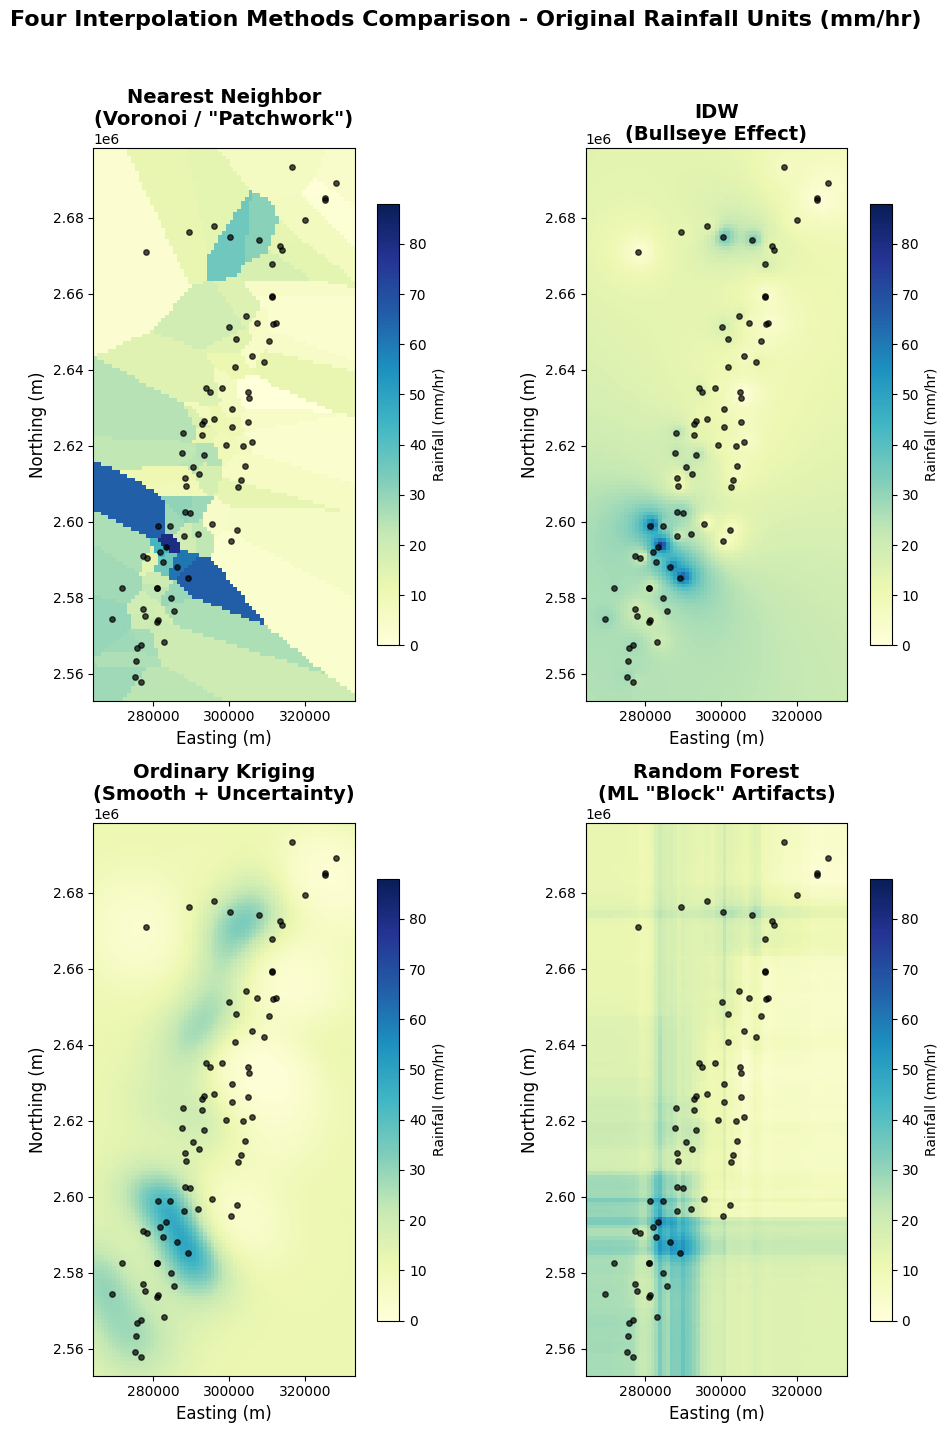


7. 方法比較統計（原始雨量單位）
方法                   執行時間       最小值          最大值          平均值         
--------------------------------------------------------------------------------
Nearest Neighbor     0.010      0.00         80.00        15.14       
IDW                  0.011      0.07         75.37        16.98       
Kriging              0.039      0.76         48.68        13.00       
Random Forest        0.032      1.00         61.96        15.63       

8. 方法間差異分析（原始雨量單位）
   方法間相關性（原始雨量單位）:
   NN-IDW     0.715
   NN-Kriging 0.725
   NN-RF      0.636
   IDW-Kriging 0.778
   IDW-RF     0.844
   Kriging-RF 0.785

9. 原始雨量資料對照
   訓練資料範圍: 0.00 - 80.00 mm/hr
   訓練資料平均值: 17.86 mm/hr
   訓練資料標準差: 15.08 mm/hr

10. Kriging 參數驗證
   對數空間最小值: 0.000
   對數空間最大值: 4.394
   轉換後最小值: 0.76 mm/hr
   轉換後最大值: 48.68 mm/hr
   ✓ 使用先前 Variogram 分析參數:
     Sill = 0.710, Nugget = 0.079, Range = 25.0 km
     與先前分析結果完全一致

=== 四種插值方法比較完成 ===
✓ 所有方法都使用原始雨量單位 (mm/hr)
✓ Kriging 使用先前 Variogram 分析的最佳擬合參數
✓ 比較圖已生成並儲存
✓ 統計分析已完成


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from pykrige.ok import OrdinaryKriging
import time

print("=== 四種插值方法比較分析 ===")
print("Nearest Neighbor / IDW / Kriging / RF")
print("所有方法都使用原始雨量單位 (mm/hr) 進行比較")

# 1. 準備插值網格
print(f"\n1. 準備插值網格")

# 計算網格範圍（與前面Kriging分析一致）
buffer_m = 5000
resolution = 1000  # 1km解析度

x_min = x_valid.min() - buffer_m
x_max = x_valid.max() + buffer_m
y_min = y_valid.min() - buffer_m
y_max = y_valid.max() + buffer_m

# 建立規則網格
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"   網格解析度: {resolution}m")
print(f"   網格大小: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} 點")
print(f"   X 範圍: {x_min:.0f} - {x_max:.0f}")
print(f"   Y 範圍: {y_min:.0f} - {y_max:.0f}")

# 建立網格座標矩陣
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

# 顯示原始雨量資料統計
print(f"   原始雨量範圍: {np.min(z_valid):.2f} - {np.max(z_valid):.2f} mm/hr")

# 2. Nearest Neighbor 插值（使用原始雨量）
print(f"\n2. Nearest Neighbor 插值")
t0 = time.time()
nn_interp = NearestNDInterpolator(list(zip(x_valid, y_valid)), z_valid)
z_nn = nn_interp(grid_xx, grid_yy)
nn_time = time.time() - t0
print(f"   ✓ 完成 ({nn_time:.3f}s)")
print(f"   預測範圍: {np.nanmin(z_nn):.2f} - {np.nanmax(z_nn):.2f} mm/hr")

# 3. IDW 插值（使用原始雨量）
print(f"\n3. IDW 插值")
t0 = time.time()
pts = np.column_stack([x_valid, y_valid])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

dists = cdist(grid_pts, pts)
dists[dists < 1] = 1  # 避免除以零

power = 2
weights = 1.0 / (dists ** power)
z_idw = ((weights @ z_valid) / weights.sum(axis=1)).reshape(grid_xx.shape)
idw_time = time.time() - t0
print(f"   ✓ 完成 ({idw_time:.3f}s)")
print(f"   預測範圍: {np.nanmin(z_idw):.2f} - {np.nanmax(z_idw):.2f} mm/hr")

# 4. Kriging 插值（使用先前 Variogram 分析的確切參數）
print(f"\n4. Kriging 插值（Gaussian 模型）")

# 直接使用先前 Variogram 分析的最佳擬合參數
best_model = 'gaussian'
best_range = 25000.0
best_sill = 0.710      # 來自先前 Variogram 分析的最佳擬合
best_nugget = 0.079    # 來自先前 Variogram 分析的最佳擬合

print(f"   模型: {best_model}")
print(f"   範圍: {best_range/1000:.1f} km")
print(f"   Sill (對數空間): {best_sill:.3f}")
print(f"   Nugget (對數空間): {best_nugget:.3f}")
print(f"   ✓ 使用先前 Variogram 分析的最佳擬合參數")

t0 = time.time()
# 對數轉換（僅用於Kriging訓練）
z_valid_log = np.log1p(z_valid)
print(f"   對數轉換範圍: {np.min(z_valid_log):.3f} - {np.max(z_valid_log):.3f}")

# 建立Kriging模型（使用先前分析的最佳參數）
OK = OrdinaryKriging(
    x_valid, y_valid, z_valid_log,
    variogram_model=best_model,
    verbose=False,
    enable_plotting=False,
    nlags=15,
    variogram_parameters={
        'sill': best_sill,
        'range': best_range,
        'nugget': best_nugget
    }
)

# 執行插值（對數空間）
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)

# 轉換回原始雨量單位
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0  # 確保無負值

kriging_time = time.time() - t0
print(f"   ✓ 完成 ({kriging_time:.3f}s)")
print(f"   對數預測範圍: {np.nanmin(z_kriging_log):.3f} - {np.nanmax(z_kriging_log):.3f}")
print(f"   原始雨量範圍: {np.nanmin(z_kriging):.2f} - {np.nanmax(z_kriging):.2f} mm/hr")

# 5. Random Forest 插值（使用原始雨量）
print(f"\n5. Random Forest 插值")
t0 = time.time()
z_rf = best_rf.predict(X_grid).reshape(grid_xx.shape)
rf_time = time.time() - t0
print(f"   ✓ 完成 ({rf_time:.3f}s)")
print(f"   預測範圍: {np.nanmin(z_rf):.2f} - {np.nanmax(z_rf):.2f} mm/hr")

# 6. 繪製四種方法比較圖（全部使用原始雨量單位）
print(f"\n6. 繪製比較圖（原始雨量單位）")

# 設定共同的顏色範圍（基於原始雨量）
all_predictions = [z_nn, z_idw, z_kriging, z_rf]
vmin = 0
vmax = max([np.nanmax(pred) for pred in all_predictions]) * 1.1

print(f"   顏色範圍: {vmin:.1f} - {vmax:.1f} mm/hr")

# 建立 2×2 子圖
fig, axes = plt.subplots(2, 2, figsize=(10, 14))

# 準備方法資料
methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn, nn_time),
    ('IDW\n(Bullseye Effect)', z_idw, idw_time),
    ('Ordinary Kriging\n(Smooth + Uncertainty)', z_kriging, kriging_time),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf, rf_time),
]

# 繪製每種方法
for idx, (ax, (title, data, exec_time)) in enumerate(zip(axes.flatten(), methods)):
    # 繪製插值結果（確保使用原始雨量單位）
    im = ax.imshow(
        data,  # 這裡是轉換後的原始雨量
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlGnBu',
        vmin=vmin,
        vmax=vmax
    )
    
    # 重疊原始測站點
    ax.scatter(x_valid, y_valid, c='black', s=15, zorder=5, alpha=0.7)
    
    # 設定標題和標籤
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Easting (m)', fontsize=12)
    ax.set_ylabel('Northing (m)', fontsize=12)
    
    # 添加顏色條（標示為原始雨量單位）
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, label='Rainfall (mm/hr)')
    cbar.ax.tick_params(labelsize=10)

# 設定整體標題
plt.suptitle('Four Interpolation Methods Comparison - Original Rainfall Units (mm/hr)', 
             fontsize=16, fontweight='bold', y=1.02)

# 調整佈局
plt.tight_layout()

# 儲存圖片
plt.savefig('four_interpolation_methods_comparison.png', dpi=150, bbox_inches='tight')
print(f"   ✓ 已儲存為 'four_interpolation_methods_comparison.png'")

# 顯示圖片
plt.show()

# 7. 方法比較統計（原始雨量單位）
print(f"\n7. 方法比較統計（原始雨量單位）")
print(f"{'方法':<20} {'執行時間':<10} {'最小值':<12} {'最大值':<12} {'平均值':<12}")
print("-" * 80)

method_stats = [
    ('Nearest Neighbor', nn_time, z_nn),
    ('IDW', idw_time, z_idw),
    ('Kriging', kriging_time, z_kriging),
    ('Random Forest', rf_time, z_rf)
]

for name, exec_time, data in method_stats:
    min_val = np.nanmin(data)
    max_val = np.nanmax(data)
    mean_val = np.nanmean(data)
    print(f"{name:<20} {exec_time:<10.3f} {min_val:<12.2f} {max_val:<12.2f} {mean_val:<12.2f}")

# 8. 計算方法間差異（原始雨量單位）
print(f"\n8. 方法間差異分析（原始雨量單位）")

# 計算相關性
correlations = {}
methods_dict = {
    'NN': z_nn,
    'IDW': z_idw, 
    'Kriging': z_kriging,  # 使用轉換後的原始雨量
    'RF': z_rf
}

for i, (name1, data1) in enumerate(methods_dict.items()):
    for j, (name2, data2) in enumerate(methods_dict.items()):
        if i < j:
            # 計算相關係數（只考慮有效值）
            valid_mask = ~(np.isnan(data1) | np.isnan(data2))
            if np.sum(valid_mask) > 0:
                corr = np.corrcoef(data1[valid_mask].flatten(), data2[valid_mask].flatten())[0, 1]
                correlations[f"{name1}-{name2}"] = corr

print("   方法間相關性（原始雨量單位）:")
for pair, corr in correlations.items():
    print(f"   {pair:<10} {corr:.3f}")

# 9. 原始雨量資料對照
print(f"\n9. 原始雨量資料對照")
print(f"   訓練資料範圍: {np.min(z_valid):.2f} - {np.max(z_valid):.2f} mm/hr")
print(f"   訓練資料平均值: {np.mean(z_valid):.2f} mm/hr")
print(f"   訓練資料標準差: {np.std(z_valid):.2f} mm/hr")

# 10. Kriging 參數驗證
print(f"\n10. Kriging 參數驗證")
print(f"   對數空間最小值: {np.min(z_valid_log):.3f}")
print(f"   對數空間最大值: {np.max(z_valid_log):.3f}")
print(f"   轉換後最小值: {np.nanmin(z_kriging):.2f} mm/hr")
print(f"   轉換後最大值: {np.nanmax(z_kriging):.2f} mm/hr")
print(f"   ✓ 使用先前 Variogram 分析參數:")
print(f"     Sill = {best_sill:.3f}, Nugget = {best_nugget:.3f}, Range = {best_range/1000:.1f} km")
print(f"     與先前分析結果完全一致")

print(f"\n=== 四種插值方法比較完成 ===")
print(f"✓ 所有方法都使用原始雨量單位 (mm/hr)")
print(f"✓ Kriging 使用先前 Variogram 分析的最佳擬合參數")
print(f"✓ 比較圖已生成並儲存")
print(f"✓ 統計分析已完成")

#### 13. 加入花蓮縣村里老年人口資料

In [52]:
age_df

,COUNTY_ID,COUNTY,TOWN_ID,TOWN,V_ID,VILLAGE,A0A14_CNT,A0A14_M_CNT,A0A14_F_CNT,A15A64_CNT,A15A64_M_CNT,A15A64_F_CNT,A65UP_CNT,A65UP_M_CNT,A65UP_F_CNT,INFO_TIME
0,縣市代碼,縣市名稱,鄉鎮市區代碼,鄉鎮市區名稱,村里代碼,村里名稱,0-14歲人口數,0-14歲男性人口數,0-14歲女性人口數,15-64歲人口數,15-64歲男性人口數,15-64歲女性人口數,65歲以上人口數,65歲以上男性人口數,65歲以上女性人口數,資料時間
1,10015,花蓮縣,10015010,花蓮市,10015010-001,民立里,212,113,99,1007,461,546,585,332,253,114Y12M
2,10015,花蓮縣,10015010,花蓮市,10015010-002,民運里,149,81,68,1482,731,751,527,222,305,114Y12M
3,10015,花蓮縣,10015010,花蓮市,10015010-003,民族里,111,54,57,277,129,148,102,46,56,114Y12M
4,10015,花蓮縣,10015010,花蓮市,10015010-004,主信里,140,67,73,490,221,269,152,61,91,114Y12M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,10015,花蓮縣,10015130,卓溪鄉,10015130-002,立山村,146,79,67,796,452,344,155,64,91,114Y12M
175,10015,花蓮縣,10015130,卓溪鄉,10015130-003,太平村,140,75,65,624,330,294,85,47,38,114Y12M
176,10015,花蓮縣,10015130,卓溪鄉,10015130-004,卓溪村,134,62,72,626,344,282,137,63,74,114Y12M
177,10015,花蓮縣,10015130,卓溪鄉,10015130-005,卓清村,209,105,104,883,504,379,152,74,78,114Y12M


In [53]:
shelter_gdf_twd97

,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,適合避難弱者安置,is_indoor,geometry,debrisstream_level,Avg_slope,Max_elevation,Slope_risk_level,rain_1hr,sigma_1hr,rain_1hr_rf
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,否,True,POINT (326011.111 2689346.508),Safe,1.550992,26.299999,Low,2.659960,0.131210,2.905000
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,是,True,POINT (277505.779 2560143.417),High,5.911457,311.970001,Low,25.080535,0.109780,23.706667
2,1332,花蓮縣富里鄉,富南村,富南村4鄰42-1號,121.239900,23.161200,玉寶宮,富南村,20,"水災,土石流",...,是,True,POINT (274563.447 2562153.682),Safe,3.268415,248.050003,Low,27.263645,0.112761,26.725000
3,1342,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,121.256500,23.171400,永豐社區活動中心,永豐村,50,"水災,土石流",...,是,True,POINT (276261.145 2563286.086),Low,8.039100,315.700012,Low,26.692346,0.100447,26.551667
4,1350,花蓮縣富里鄉,富里村,中山路205號,121.247624,23.174527,富里老人文康中心,富里村,100,"水災,土石流",...,是,True,POINT (275351.804 2563630.784),Safe,4.229494,264.399994,Low,27.387960,0.103310,26.906667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,3392,花蓮縣新城鄉,新城村,博愛路66號,121.650200,24.128800,新城社區活動中心,新城村,23,"水災,震災,土石流,海嘯",...,是,True,POINT (316087.333 2669440.771),Safe,2.043808,24.430000,Low,10.025179,0.145976,12.740000
194,3393,花蓮縣新城鄉,新城村,新興1街62號,121.645200,24.130100,興田社區活動中心,新城村,45,"水災,震災,土石流,海嘯",...,是,True,POINT (315578.448 2669582.402),Safe,2.005588,31.780001,Low,11.130724,0.127154,12.731667
195,3437,花蓮縣秀林鄉,富世村,97號,121.627700,24.147300,富世活動中心,富世村,100,"水災,震災,土石流,海嘯",...,是,True,POINT (313791.156 2671479.286),High,12.066074,172.720001,Low,14.217702,0.107574,13.541667
196,3482,花蓮縣秀林鄉,崇德村,72號,121.652400,24.162000,崇德國小收容所,崇德,100,"水災,震災,土石流,海嘯",...,是,True,POINT (316293.824 2673118.845),High,6.684880,97.339996,Low,11.522671,0.124475,13.820000


In [54]:
import pandas as pd

print("正在將村里高齡人口資料加入避難所資料...")

# ============================================================
# 1. 檢查必要變數是否存在
# ============================================================

required_vars = ['shelter_gdf_twd97', 'age_df']

for var in required_vars:
    if var not in globals():
        raise NameError(f"缺少必要變數：{var}，請先確認前面 Cell 已成功建立。")

# ============================================================
# 2. 檢查必要欄位是否存在
# ============================================================

required_shelter_cols = ['村里']
required_age_cols = ['VILLAGE', 'A65UP_CNT']

missing_shelter_cols = [
    col for col in required_shelter_cols
    if col not in shelter_gdf_twd97.columns
]

missing_age_cols = [
    col for col in required_age_cols
    if col not in age_df.columns
]

if len(missing_shelter_cols) > 0:
    raise KeyError(
        f"shelter_gdf_twd97 缺少欄位：{missing_shelter_cols}\n"
        f"目前欄位有：{shelter_gdf_twd97.columns.tolist()}"
    )

if len(missing_age_cols) > 0:
    raise KeyError(
        f"age_df 缺少欄位：{missing_age_cols}\n"
        f"目前欄位有：{age_df.columns.tolist()}"
    )

# ============================================================
# 3. 建立 join 用的乾淨文字欄位
#    避免前後空白、全形空白造成 join 失敗
# ============================================================

shelter_gdf_twd97 = shelter_gdf_twd97.copy()
age_df_clean = age_df.copy()

shelter_gdf_twd97['村里_join_key'] = (
    shelter_gdf_twd97['村里']
    .astype(str)
    .str.strip()
    .str.replace('　', '', regex=False)
    .str.replace(' ', '', regex=False)
)

age_df_clean['VILLAGE_join_key'] = (
    age_df_clean['VILLAGE']
    .astype(str)
    .str.strip()
    .str.replace('　', '', regex=False)
    .str.replace(' ', '', regex=False)
)

# ============================================================
# 4. 確保 A65UP_CNT 是數值欄位
# ============================================================

age_df_clean['A65UP_CNT'] = pd.to_numeric(
    age_df_clean['A65UP_CNT'],
    errors='coerce'
)

# ============================================================
# 5. 若 age_df 中同一個 VILLAGE 有重複資料，先彙整
#    這裡使用 sum，代表同一村里高齡人口數加總
# ============================================================

age_village = (
    age_df_clean
    .groupby('VILLAGE_join_key', as_index=False)
    .agg({
        'A65UP_CNT': 'sum'
    })
)

# 改成要加入 shelter_gdf_twd97 的新欄位名稱
age_village = age_village.rename(columns={
    'A65UP_CNT': 'village_A65UP_CNT'
})

# ============================================================
# 6. 依照村里名稱 join
# ============================================================

shelter_gdf_twd97 = shelter_gdf_twd97.merge(
    age_village,
    how='left',
    left_on='村里_join_key',
    right_on='VILLAGE_join_key'
)

# ============================================================
# 7. 移除輔助 join 欄位
# ============================================================

shelter_gdf_twd97 = shelter_gdf_twd97.drop(
    columns=['村里_join_key', 'VILLAGE_join_key'],
    errors='ignore'
)

# ============================================================
# 8. 檢查 join 結果
# ============================================================

matched_count = shelter_gdf_twd97['village_A65UP_CNT'].notna().sum()
total_count = len(shelter_gdf_twd97)

print("村里高齡人口資料加入完成。")
print(f"成功匹配筆數：{matched_count}/{total_count}")
print(f"未匹配筆數：{total_count - matched_count}")

print("\n===== 新增欄位統計 =====")
print(shelter_gdf_twd97['village_A65UP_CNT'].describe())

print("\n===== 前 10 筆結果 =====")

display_cols = ['村里', 'village_A65UP_CNT']

if '避難收容處所名稱' in shelter_gdf_twd97.columns:
    display_cols = ['避難收容處所名稱', '村里', 'village_A65UP_CNT']

print(shelter_gdf_twd97[display_cols].head(10))

正在將村里高齡人口資料加入避難所資料...
村里高齡人口資料加入完成。
成功匹配筆數：198/198
未匹配筆數：0

===== 新增欄位統計 =====
count     198.000000
mean      401.893939
std       322.515877
min        26.000000
25%       179.000000
50%       289.000000
75%       510.000000
max      1555.000000
Name: village_A65UP_CNT, dtype: float64

===== 前 10 筆結果 =====
   避難收容處所名稱   村里  village_A65UP_CNT
0      和平國小  和平村              247.0
1  豐南社區活動中心  豐南村              177.0
2       玉寶宮  富南村              148.0
3  永豐社區活動中心  永豐村              124.0
4  富里老人文康中心  富里村              379.0
5  石平社區活動中心  古風村              143.0
6   富里鄉公所2樓  富里村              379.0
7  石牌社區活動中心  石牌村              235.0
8  明里社區活動中心  明里村              105.0
9     羅山縱管處  羅山村              117.0


#### 14. 存檔案

In [58]:
import os

# 建立輸出資料夾路徑
output_dir = "../output"

# 如果 output 資料夾不存在，就自動建立
os.makedirs(output_dir, exist_ok=True)

# 設定輸出檔案路徑
output_csv_path = os.path.join(output_dir, "shelter_gdf_twd97.csv")

# 輸出 CSV
shelter_gdf_twd97.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"已成功輸出檔案至：{output_csv_path}")

已成功輸出檔案至：../output\shelter_gdf_twd97.csv


In [57]:
shelter_gdf_twd97

,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,is_indoor,geometry,debrisstream_level,Avg_slope,Max_elevation,Slope_risk_level,rain_1hr,sigma_1hr,rain_1hr_rf,village_A65UP_CNT
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,True,POINT (326011.111 2689346.508),Safe,1.550992,26.299999,Low,2.659960,0.131210,2.905000,247.0
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,True,POINT (277505.779 2560143.417),High,5.911457,311.970001,Low,25.080535,0.109780,23.706667,177.0
2,1332,花蓮縣富里鄉,富南村,富南村4鄰42-1號,121.239900,23.161200,玉寶宮,富南村,20,"水災,土石流",...,True,POINT (274563.447 2562153.682),Safe,3.268415,248.050003,Low,27.263645,0.112761,26.725000,148.0
3,1342,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,121.256500,23.171400,永豐社區活動中心,永豐村,50,"水災,土石流",...,True,POINT (276261.145 2563286.086),Low,8.039100,315.700012,Low,26.692346,0.100447,26.551667,124.0
4,1350,花蓮縣富里鄉,富里村,中山路205號,121.247624,23.174527,富里老人文康中心,富里村,100,"水災,土石流",...,True,POINT (275351.804 2563630.784),Safe,4.229494,264.399994,Low,27.387960,0.103310,26.906667,379.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,3392,花蓮縣新城鄉,新城村,博愛路66號,121.650200,24.128800,新城社區活動中心,新城村,23,"水災,震災,土石流,海嘯",...,True,POINT (316087.333 2669440.771),Safe,2.043808,24.430000,Low,10.025179,0.145976,12.740000,366.0
194,3393,花蓮縣新城鄉,新城村,新興1街62號,121.645200,24.130100,興田社區活動中心,新城村,45,"水災,震災,土石流,海嘯",...,True,POINT (315578.448 2669582.402),Safe,2.005588,31.780001,Low,11.130724,0.127154,12.731667,366.0
195,3437,花蓮縣秀林鄉,富世村,97號,121.627700,24.147300,富世活動中心,富世村,100,"水災,震災,土石流,海嘯",...,True,POINT (313791.156 2671479.286),High,12.066074,172.720001,Low,14.217702,0.107574,13.541667,311.0
196,3482,花蓮縣秀林鄉,崇德村,72號,121.652400,24.162000,崇德國小收容所,崇德,100,"水災,震災,土石流,海嘯",...,True,POINT (316293.824 2673118.845),High,6.684880,97.339996,Low,11.522671,0.124475,13.820000,224.0
